# Pontifícia Universidade Católica do Rio de Janeiro (PUC-Rio)

## Pós-Graduação em Ciência de Dados & Analytics

### MVP de Machine Learning & Analytics

---

# Aplicação de Machine Learning na Classificação de Operações do Contrato Futuro do Ibovespa (WINFUT): Um Estudo Baseado em Estratégias de Take Profit e Stop Loss

## Um estudo sobre a probabilidade de uma operação atingir um Take Profit de 450 pontos antes de um Stop Loss de 150 pontos

---

### Aluno

**Carlos Peter Jost**

### Curso

**Pós-Graduação em Ciência de Dados & Analytics**

### Disciplina

**Machine Learning

---

## Resumo

Este trabalho apresenta o desenvolvimento de um modelo de Machine Learning aplicado ao mercado financeiro, utilizando dados históricos do contrato futuro do índice Ibovespa (WINFUT).

O objetivo é investigar se algoritmos de classificação supervisionada são capazes de identificar operações de compra com maior probabilidade de atingir um **Take Profit de 450 pontos** antes de um **Stop Loss de 150 pontos**, utilizando apenas informações disponíveis no momento da entrada da operação.

Para isso, serão utilizados dados históricos em candles de cinco minutos, técnicas de engenharia de atributos, modelos supervisionados de classificação e métodos de otimização de hiperparâmetros. Ao final, os modelos serão comparados utilizando métricas apropriadas de classificação, permitindo avaliar sua capacidade de generalização e sua aplicabilidade ao problema proposto.

---

# Sumário

1. Introdução

2. Definição do Problema

3. Descrição dos Dados

4. Análise Exploratória dos Dados

5. Preparação e Engenharia dos Dados

6. Construção da Variável-Alvo

7. Divisão dos Dados

8. Modelagem e Avaliação dos Modelos

9. Otimização de Hiperparâmetros

10. Conclusão

11. Checklist do MVP

# 1. Introdução

O mercado financeiro é caracterizado por sua elevada complexidade, grande volume de informações e comportamento altamente dinâmico. No mercado futuro, pequenas variações nos preços podem gerar ganhos ou perdas significativas em poucos minutos, tornando a tomada de decisão um dos principais desafios enfrentados por traders e investidores.

Nos últimos anos, técnicas de Machine Learning vêm sendo amplamente utilizadas como ferramentas de apoio à decisão em aplicações financeiras. Diferentemente das abordagens tradicionais baseadas exclusivamente em indicadores técnicos ou regras fixas de negociação, algoritmos de aprendizado de máquina possuem capacidade de identificar padrões complexos presentes em grandes volumes de dados históricos, permitindo estimar probabilidades e apoiar decisões de forma mais objetiva.

Neste contexto, este projeto propõe o desenvolvimento de um modelo de Machine Learning aplicado ao contrato futuro do Índice Bovespa (WINFUT), utilizando dados históricos em candles de cinco minutos. O objetivo é investigar se informações disponíveis no momento da abertura de uma operação são suficientes para classificar operações com maior probabilidade de atingir um alvo de lucro antes de alcançar um limite de perda previamente estabelecido.

O desenvolvimento deste MVP contempla todas as etapas clássicas de um projeto de Machine Learning, incluindo análise exploratória dos dados, preparação do conjunto de dados, engenharia de atributos, construção da variável-alvo, treinamento e comparação de diferentes modelos supervisionados, otimização de hiperparâmetros e avaliação dos resultados obtidos.

## Premissas do Projeto

Para garantir consistência metodológica e evitar vieses durante o desenvolvimento do modelo, foram adotadas as seguintes premissas:

- Consideram-se apenas operações de compra (*long*);
- A variável-alvo é construída utilizando uma estratégia fixa de risco-retorno;
- Todos os atributos preditores utilizam exclusivamente informações disponíveis até o momento da abertura da operação;
- Não foram considerados custos operacionais, corretagem, emolumentos ou slippage;
- A avaliação dos modelos respeita integralmente a ordem cronológica da série temporal, evitando vazamento de informações (*Data Leakage*).

## Restrições do Projeto
- Este MVP tem como objetivo avaliar a viabilidade da aplicação de Machine Learning ao problema proposto, não sendo realizada validação em dados de períodos futuros independentes (out-of-sample) além da divisão cronológica adotada neste estudo.
Durante o desenvolvimento deste projeto foram consideradas as seguintes restrições:

- O estudo foi realizado exclusivamente utilizando dados históricos do contrato futuro do Índice Bovespa (WINFUT), não sendo avaliados outros ativos financeiros.
- A estratégia analisada considera apenas operações de compra (*long*), não contemplando operações de venda (*short*).
- O alvo de lucro (450 pontos) e o limite de perda (150 pontos) permaneceram fixos durante todo o estudo, não sendo investigadas outras relações entre risco e retorno.
- O modelo foi desenvolvido utilizando apenas informações provenientes do histórico de preços e volume, não considerando fatores externos, como notícias, indicadores econômicos, fluxo de ordens ou dados fundamentalistas.
- Custos operacionais, corretagem, emolumentos, impostos e slippage não foram considerados na construção da variável-alvo.
- O desempenho dos modelos foi avaliado apenas sobre o conjunto de dados disponível, podendo variar em diferentes períodos de mercado ou em cenários de elevada volatilidade.

# 2. Definição do Problema

## Objetivo da Seção

Nesta seção será apresentado o problema de pesquisa, o objetivo do modelo de Machine Learning, o tipo de tarefa a ser resolvida, a justificativa para utilização de técnicas de aprendizado de máquina e as principais premissas consideradas durante o desenvolvimento deste MVP.

---

## Descrição do Problema

O contrato futuro do índice Ibovespa (WINFUT) é um dos ativos mais negociados da bolsa brasileira, apresentando elevada liquidez e intensa movimentação intradiária. Em razão dessas características, milhares de operações são realizadas diariamente por traders que buscam identificar oportunidades de compra e venda utilizando diferentes estratégias de negociação.

Entretanto, mesmo com o uso de indicadores técnicos e métodos tradicionais de análise, permanece o desafio de identificar objetivamente quais condições de mercado apresentam maior probabilidade de resultar em operações bem-sucedidas.

Neste trabalho, o problema consiste em desenvolver um modelo de Machine Learning capaz de classificar operações de compra no WINFUT de acordo com sua probabilidade de atingir um objetivo de lucro antes de atingir um limite máximo de perda.

---

## Objetivo do Modelo

O objetivo deste projeto é construir modelos de Machine Learning capazes de identificar operações com maior probabilidade de sucesso considerando uma estratégia operacional composta por:

- Take Profit de **450 pontos**;
- Stop Loss de **150 pontos**;
- Relação risco-retorno de **1:3**.

Espera-se que os modelos aprendam padrões presentes nos dados históricos e consigam diferenciar operações vencedoras de operações perdedoras utilizando apenas informações disponíveis no momento da entrada.

---

## Tipo de Problema

Este projeto será tratado como um problema de **Classificação Binária Supervisionada**.

Cada observação receberá uma das seguintes classes:

- **Classe 1:** o preço atingiu primeiro o Take Profit de 450 pontos;
- **Classe 0:** o preço atingiu primeiro o Stop Loss de 150 pontos.

Operações próximas ao final da base histórica que não atingem nenhuma das duas barreiras até o último registro disponível (casos censurados) não possuem desfecho definido e são removidas do conjunto de dados, conforme detalhado na Seção 6.

Embora o conjunto de dados seja uma série temporal financeira, o objetivo deste trabalho não é prever o preço futuro do ativo, mas sim classificar o resultado de uma operação previamente definida.

---

## Justificativa para o uso de Machine Learning

O comportamento do mercado financeiro é influenciado por diversos fatores simultaneamente, como tendência, volatilidade, momentum e volume negociado. Essas relações costumam ser não lineares e de difícil modelagem por regras determinísticas.

Modelos de Machine Learning possuem capacidade de aprender esses padrões diretamente a partir dos dados históricos, tornando-se adequados para estimar a probabilidade de sucesso de uma operação sem depender exclusivamente de regras fixas de análise técnica.

---

## Premissas

Para o desenvolvimento deste MVP foram adotadas as seguintes premissas:

- Cada candle de cinco minutos representa uma possível oportunidade de entrada compradora;
- Todas as operações utilizam Stop Loss fixo de 150 pontos e Take Profit fixo de 450 pontos;
- Apenas informações disponíveis até o instante da entrada serão utilizadas como variáveis explicativas;
- Custos operacionais, corretagem, emolumentos e slippage não serão considerados;
- A divisão entre treino e teste respeitará rigorosamente a ordem cronológica dos dados.


# 3. Descrição dos Dados

## Objetivo da Seção

Nesta etapa será apresentado o conjunto de dados utilizado no desenvolvimento do projeto, sua origem, estrutura, principais variáveis e limitações, bem como a estratégia utilizada para seu carregamento e utilização durante o treinamento dos modelos.

---

## Dataset Utilizado

O conjunto de dados utilizado neste estudo é composto por cotações históricas do contrato futuro do índice Ibovespa (WINFUT), organizadas em candles de cinco minutos.

Cada registro representa um intervalo de negociação contendo informações sobre preços e volume negociado, permitindo reconstruir o comportamento do mercado ao longo do período analisado.

---

## Fonte dos Dados

Os dados foram originalmente extraídos da plataforma **Profit Pro (Nelogica)**.

Para garantir a reprodutibilidade do projeto, o arquivo será disponibilizado em um repositório público no GitHub e carregado diretamente no notebook por meio de uma URL pública.

---

## Estrutura do Dataset

Após o carregamento dos dados serão apresentados automaticamente:

- quantidade de registros;
- quantidade de atributos;
- tipos das variáveis;
- primeiras observações do conjunto de dados.

---

## Principais Variáveis

O conjunto de dados contém, entre outras, as seguintes variáveis:

- Ativo;
- Data;
- Hora;
- Abertura;
- Máxima;
- Mínima;
- Fechamento;
- Volume;
- Quantidade.

Essas variáveis servirão como base para a construção dos atributos utilizados pelos modelos de Machine Learning.

---

## Variável-Alvo

O dataset original não possui uma variável-alvo.

A variável **Target** será construída durante a preparação dos dados.

Para cada candle será simulada uma operação de compra utilizando:

- Stop Loss = 150 pontos;
- Take Profit = 450 pontos.

Caso o preço atinja primeiro o Take Profit, a observação receberá valor **1**.

Caso o Stop Loss seja atingido primeiro, receberá valor **0**.

---

## Limitações do Dataset

Algumas limitações devem ser consideradas:

- O estudo utiliza apenas um ativo financeiro;
- O conjunto de dados não contempla notícias econômicas nem eventos macroeconômicos;
- Custos operacionais e slippage não são considerados;
- O desempenho obtido refere-se exclusivamente ao período histórico analisado.

# 4. Análise Exploratória dos Dados

## Objetivo da Seção

Antes do treinamento dos modelos de Machine Learning, é fundamental compreender a estrutura do conjunto de dados. Nesta etapa serão analisadas as características gerais do dataset, incluindo sua dimensão, tipos de variáveis, estatísticas descritivas, presença de valores ausentes e distribuição dos principais atributos.

Essa análise permite identificar possíveis inconsistências e orientar as etapas de preparação e engenharia de atributos que serão realizadas posteriormente.

In [1]:
# ==========================================================
# Configurações
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

import time

RANDOM_STATE = 42

# ==========================================================
# Bibliotecas Numéricas
# ==========================================================

import numpy as np
import pandas as pd

np.random.seed(RANDOM_STATE)

# ==========================================================
# Visualização
# ==========================================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

# ==========================================================
# Machine Learning
# ==========================================================

from sklearn.model_selection import (
    TimeSeriesSplit,
    GridSearchCV
)

from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)


## Carregamento do Dataset

### Objetivo da Seção

Nesta etapa será realizado o carregamento do conjunto de dados diretamente de uma **URL pública** (repositório no GitHub), garantindo que o notebook possa ser executado do início ao fim sem necessidade de upload manual de arquivos, login, token ou configuração local.

Também será realizada uma primeira inspeção da estrutura dos dados, garantindo que as informações foram importadas corretamente antes do início da análise exploratória.

**Observação sobre o formato numérico:** o arquivo utiliza o padrão brasileiro de formatação, no qual o ponto (`.`) é separador de milhar e a vírgula (`,`) é separador decimal. Por esse motivo, os parâmetros `thousands="."` e `decimal=","` foram informados no carregamento, garantindo que preços, volume e quantidade sejam interpretados corretamente em suas escalas originais — em especial, os preços do WINFUT em **pontos do índice** (na casa das centenas de milhares de pontos).


In [2]:
# ==========================================================
# Carregamento do dataset a partir de URL pública (GitHub)
# ==========================================================

URL_DADOS = "https://raw.githubusercontent.com/cpjost/MVP-Machine-Learning-WINFUT/main/WINFUT_F_02_5min.csv"

df = pd.read_csv(
    URL_DADOS,
    sep=";",
    encoding="latin1",
    thousands=".",
    decimal=","
)

df.head()


,Ativo,Data,Hora,Abertura,Máximo,Mínimo,Fechamento,Volume,Quantidade
0,WINFUT,21/05/2026,18:20:00,178830,179055,178700,178700,1.221375e+09,34163
1,WINFUT,21/05/2026,18:15:00,178850,178930,178730,178825,1.399371e+09,39130
2,WINFUT,21/05/2026,18:10:00,178865,178915,178745,178850,1.297335e+09,36272
3,WINFUT,21/05/2026,18:05:00,178935,178980,178755,178865,1.907921e+09,53332
4,WINFUT,21/05/2026,18:00:00,179110,179140,178930,178945,1.589297e+09,44385


In [3]:
print(f"Registros: {df.shape[0]}")
print(f"Atributos: {df.shape[1]}")
df.info()

Registros: 56378
Atributos: 9
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56378 entries, 0 to 56377
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Ativo       56378 non-null  object 
 1   Data        56378 non-null  object 
 2   Hora        56378 non-null  object 
 3   Abertura    56378 non-null  int64  
 4   Máximo      56378 non-null  int64  
 5   Mínimo      56378 non-null  int64  
 6   Fechamento  56378 non-null  int64  
 7   Volume      56378 non-null  float64
 8   Quantidade  56378 non-null  int64  
dtypes: float64(1), int64(5), object(3)
memory usage: 3.9+ MB


In [4]:
# ==========================================================
# Verificação da escala dos preços após o carregamento
# (os preços do WINFUT são cotados em pontos do índice)
# ==========================================================

df[["Abertura", "Máximo", "Mínimo", "Fechamento"]].describe().round(0)


,Abertura,Máximo,Mínimo,Fechamento
count,56378.0,56378.0,56378.0,56378.0
mean,162222.0,162322.0,162122.0,162222.0
std,14549.0,14568.0,14530.0,14549.0
min,140354.0,140443.0,140166.0,140354.0
25%,152773.0,152872.0,152677.0,152773.0
50%,157585.0,157667.0,157499.0,157587.0
75%,168185.0,168282.0,168088.0,168185.0
max,203665.0,203833.0,203568.0,203665.0


In [5]:
# Junta Data + Hora

df["DataHora"] = pd.to_datetime(
    df["Data"] + " " + df["Hora"],
    format="%d/%m/%Y %H:%M:%S"
)

df.head()

,Ativo,Data,Hora,Abertura,Máximo,Mínimo,Fechamento,Volume,Quantidade,DataHora
0,WINFUT,21/05/2026,18:20:00,178830,179055,178700,178700,1.221375e+09,34163,2026-05-21 18:20:00
1,WINFUT,21/05/2026,18:15:00,178850,178930,178730,178825,1.399371e+09,39130,2026-05-21 18:15:00
2,WINFUT,21/05/2026,18:10:00,178865,178915,178745,178850,1.297335e+09,36272,2026-05-21 18:10:00
3,WINFUT,21/05/2026,18:05:00,178935,178980,178755,178865,1.907921e+09,53332,2026-05-21 18:05:00
4,WINFUT,21/05/2026,18:00:00,179110,179140,178930,178945,1.589297e+09,44385,2026-05-21 18:00:00


In [6]:
df = df.sort_values("DataHora").reset_index(drop=True)

df.head()

,Ativo,Data,Hora,Abertura,Máximo,Mínimo,Fechamento,Volume,Quantidade,DataHora
0,WINFUT,21/05/2024,09:00:00,161552,161608,161276,161577,1.064480e+10,329660,2024-05-21 09:00:00
1,WINFUT,21/05/2024,09:05:00,161577,161590,161313,161483,7.559748e+09,234177,2024-05-21 09:05:00
2,WINFUT,21/05/2024,09:10:00,161483,161552,161376,161477,6.675478e+09,206713,2024-05-21 09:10:00
3,WINFUT,21/05/2024,09:15:00,161477,161784,161445,161445,1.388959e+10,429719,2024-05-21 09:15:00
4,WINFUT,21/05/2024,09:20:00,161445,161571,161382,161571,6.880440e+09,213058,2024-05-21 09:20:00


In [7]:
df.tail()

,Ativo,Data,Hora,Abertura,Máximo,Mínimo,Fechamento,Volume,Quantidade,DataHora
56373,WINFUT,21/05/2026,18:00:00,179110,179140,178930,178945,1.589297e+09,44385,2026-05-21 18:00:00
56374,WINFUT,21/05/2026,18:05:00,178935,178980,178755,178865,1.907921e+09,53332,2026-05-21 18:05:00
56375,WINFUT,21/05/2026,18:10:00,178865,178915,178745,178850,1.297335e+09,36272,2026-05-21 18:10:00
56376,WINFUT,21/05/2026,18:15:00,178850,178930,178730,178825,1.399371e+09,39130,2026-05-21 18:15:00
56377,WINFUT,21/05/2026,18:20:00,178830,179055,178700,178700,1.221375e+09,34163,2026-05-21 18:20:00


## Estrutura Temporal do Dataset

Como o conjunto de dados representa uma série temporal financeira, foi necessário reorganizar os registros em ordem cronológica crescente.

Inicialmente, os dados estavam ordenados do registro mais recente para o mais antigo. Após a criação da variável `DataHora`, os registros foram reorganizados utilizando essa coluna como referência temporal.

Essa etapa é fundamental para preservar a sequência correta dos eventos e evitar vazamento de informação durante a construção da variável-alvo e a divisão entre os conjuntos de treinamento e teste.

In [8]:
# Estatísticas descritivas

df.describe()

,Abertura,Máximo,Mínimo,Fechamento,Volume,Quantidade,DataHora
count,56378.000000,56378.000000,56378.000000,56378.000000,5.637800e+04,56378.000000,56378
mean,162221.873514,162321.779932,162122.118273,162222.198145,4.512008e+09,137816.110752,2025-05-19 04:23:28.453652224
min,140354.000000,140443.000000,140166.000000,140354.000000,1.799243e+08,5749.000000,2024-05-21 09:00:00
25%,152773.000000,152872.250000,152677.000000,152773.000000,2.269499e+09,71803.250000,2024-11-12 15:51:15
50%,157585.000000,157667.000000,157499.000000,157587.000000,3.675539e+09,113606.000000,2025-05-21 17:22:30
75%,168185.000000,168282.000000,168088.000000,168185.000000,6.035063e+09,184464.500000,2025-11-13 16:53:45
max,203665.000000,203833.000000,203568.000000,203665.000000,2.893258e+10,928859.000000,2026-05-21 18:20:00
std,14548.974043,14568.334325,14529.611001,14548.803445,3.081315e+09,90883.964053,NaN


### Estatísticas Descritivas

As estatísticas descritivas permitem compreender a distribuição das principais variáveis numéricas, identificando valores mínimos, máximos, médias e medidas de dispersão.

Essas informações auxiliam na identificação de possíveis inconsistências e fornecem uma visão geral do comportamento histórico do mercado.

In [9]:
# Valores ausentes

df.isnull().sum()

,0
Ativo,0
Data,0
Hora,0
Abertura,0
Máximo,0
Mínimo,0
Fechamento,0
Volume,0
Quantidade,0
DataHora,0


### Valores Ausentes

A verificação de valores ausentes é uma etapa importante da preparação dos dados, pois registros incompletos podem comprometer o treinamento dos modelos de Machine Learning.

Nesta etapa será avaliada a existência de valores nulos em cada atributo do conjunto de dados.

In [10]:
# Linhas duplicadas

print(f"Registros duplicados: {df.duplicated().sum()}")

Registros duplicados: 0


### Registros Duplicados

Também foi realizada a verificação de registros duplicados, uma vez que observações repetidas podem introduzir viés no treinamento dos modelos e comprometer a qualidade dos resultados.

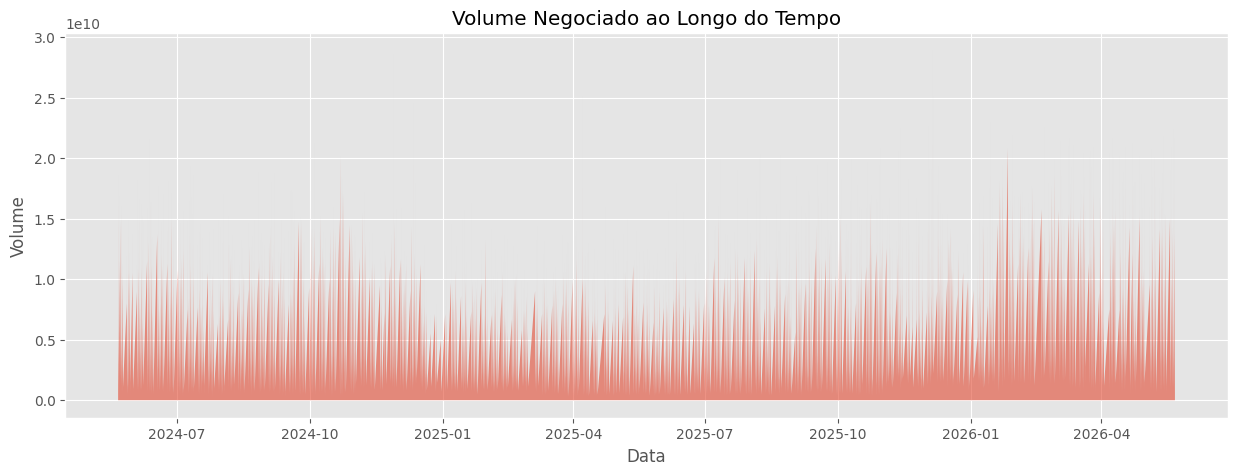

In [11]:
plt.figure(figsize=(15,5))

plt.fill_between(
    df["DataHora"],
    df["Volume"],
    alpha=0.6
)

plt.title("Volume Negociado ao Longo do Tempo")

plt.xlabel("Data")

plt.ylabel("Volume")

plt.show()

### Interpretação do Gráfico

O gráfico apresenta a evolução do volume negociado do contrato futuro do índice Bovespa (WINFUT) ao longo do período analisado.

Observa-se que o volume apresenta oscilações significativas entre os pregões, refletindo diferentes níveis de liquidez e participação dos agentes de mercado. Em alguns períodos são observados picos de negociação, indicando momentos de maior atividade, possivelmente associados à divulgação de indicadores econômicos, vencimentos de contratos ou eventos relevantes para o mercado financeiro.

Como o volume representa uma importante medida da intensidade das negociações, essa variável poderá contribuir para a construção de atributos utilizados pelos modelos de Machine Learning.

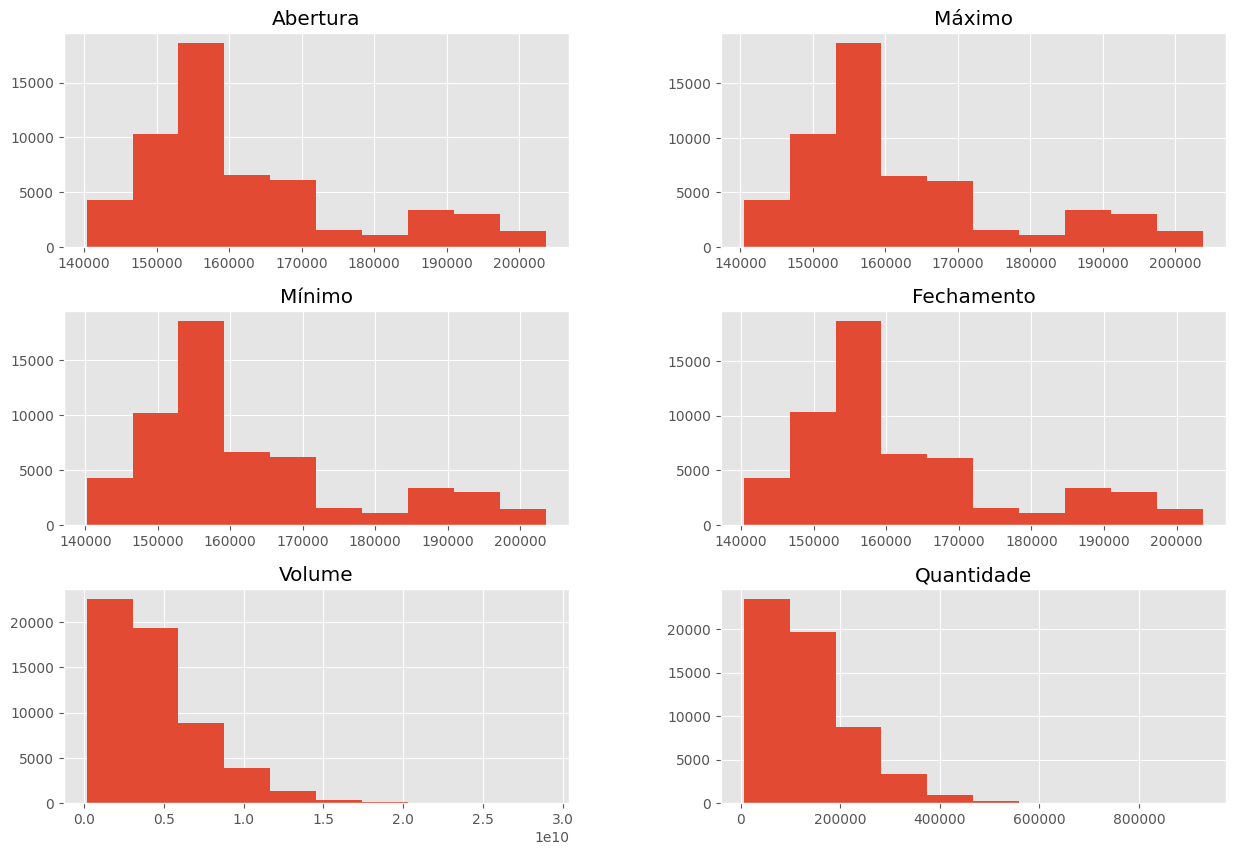

In [12]:
df_numeric = df.select_dtypes(include=np.number)

df_numeric.hist(figsize=(15,10))
plt.show()

### Interpretação dos Histogramas

Os histogramas apresentam a distribuição das principais variáveis numéricas do conjunto de dados.

Observa-se que as variáveis de preço (Abertura, Máximo, Mínimo e Fechamento) possuem distribuições semelhantes, comportamento esperado devido à forte relação existente entre os preços que compõem cada candle.

Já as variáveis Volume e Quantidade apresentam distribuições assimétricas à direita, indicando que a maior parte das observações concentra-se em valores menores, enquanto poucos registros apresentam valores significativamente elevados. Esse comportamento é característico de séries temporais financeiras.

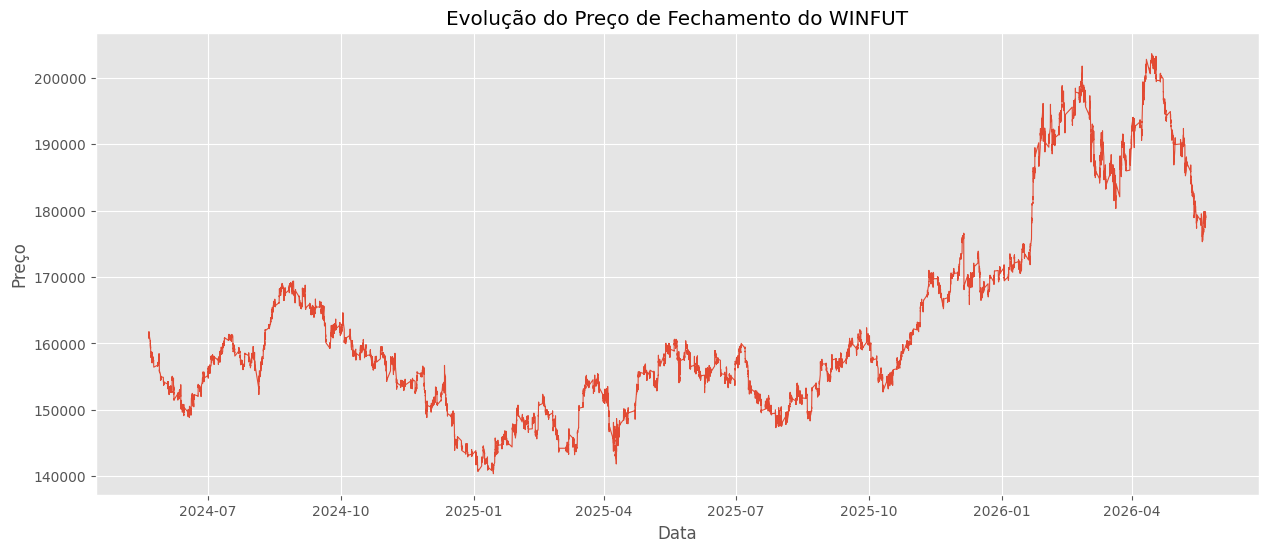

In [13]:
plt.figure(figsize=(15,6))

plt.plot(
    df["DataHora"],
    df["Fechamento"],
    linewidth=0.8
)

plt.title("Evolução do Preço de Fechamento do WINFUT")

plt.xlabel("Data")

plt.ylabel("Preço")

plt.show()

### Interpretação do Gráfico

O gráfico apresenta a evolução do preço de fechamento do contrato futuro do índice Bovespa (WINFUT) entre maio de 2024 e maio de 2026.

Observa-se que o ativo passou por diferentes regimes de mercado ao longo do período analisado, incluindo movimentos de alta, baixa e períodos de consolidação. Essa variação evidencia a dinâmica do mercado financeiro e reforça a necessidade de utilização de modelos de Machine Learning capazes de identificar padrões presentes em diferentes cenários de mercado.

A diversidade de comportamentos observada ao longo da série histórica torna o conjunto de dados adequado para o desenvolvimento de modelos supervisionados de classificação.

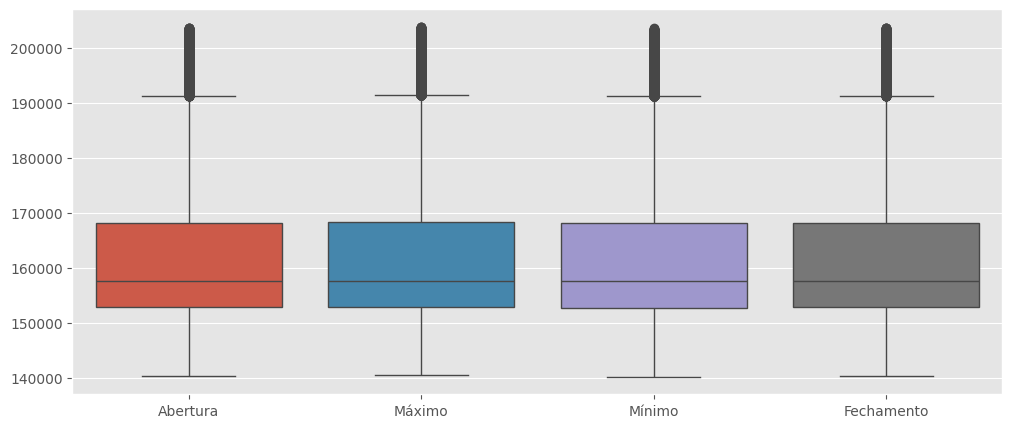

In [14]:
plt.figure(figsize=(12,5))

sns.boxplot(data=df[[
    "Abertura",
    "Máximo",
    "Mínimo",
    "Fechamento"
]])

plt.show()

### Interpretação do Gráfico

O boxplot permite visualizar a distribuição dos preços de abertura, máxima, mínima e fechamento, bem como identificar possíveis valores extremos (outliers).

Observa-se que as quatro variáveis apresentam distribuições bastante semelhantes, com medianas próximas e amplitudes compatíveis entre si. Também são identificados valores acima do limite superior, representando períodos em que o mercado atingiu níveis de preço significativamente superiores ao comportamento predominante da série.

Como esses valores correspondem a movimentos reais do mercado financeiro, eles não serão tratados como erros ou removidos do conjunto de dados, permanecendo disponíveis para o treinamento dos modelos de Machine Learning.

## Considerações da Análise Exploratória

A análise exploratória permitiu compreender a estrutura e a qualidade do conjunto de dados utilizado neste projeto.

Durante essa etapa foi possível verificar a correta organização cronológica da série temporal, confirmar a ausência de valores ausentes e registros duplicados, além de analisar a distribuição das principais variáveis de preço, volume e quantidade negociada.

Os gráficos também evidenciaram diferentes comportamentos do mercado ao longo do período analisado, demonstrando que o conjunto de dados possui variabilidade suficiente para o desenvolvimento de modelos de Machine Learning.

Com a análise exploratória concluída, o próximo passo consiste na preparação dos dados, criação da variável-alvo e engenharia de atributos que serão utilizados durante o treinamento e avaliação dos modelos.

# 5. Preparação dos Dados

## Objetivo da Seção

Nesta etapa será realizada a preparação do conjunto de dados para utilização nos modelos de Machine Learning.

Serão verificadas possíveis transformações necessárias, criados novos atributos, construída a variável-alvo do problema e adotadas medidas para evitar vazamento de informação (Data Leakage), garantindo que os modelos sejam treinados apenas com informações disponíveis no momento da tomada de decisão.

## 5.1 Tratamento dos Dados

Antes da construção dos modelos, algumas transformações são necessárias para adequar o conjunto de dados às etapas seguintes do projeto.

Nesta fase serão removidos atributos que não serão utilizados na modelagem, bem como realizadas conversões de tipos de dados quando necessário.

In [15]:
df_model = df.copy()

# Remover colunas que não serão utilizadas como atributos

df_model.drop(
    columns=[
        "Ativo",
        "Data",
        "Hora"
    ],
    inplace=True
)

df_model.head()

,Abertura,Máximo,Mínimo,Fechamento,Volume,Quantidade,DataHora
0,161552,161608,161276,161577,1.064480e+10,329660,2024-05-21 09:00:00
1,161577,161590,161313,161483,7.559748e+09,234177,2024-05-21 09:05:00
2,161483,161552,161376,161477,6.675478e+09,206713,2024-05-21 09:10:00
3,161477,161784,161445,161445,1.388959e+10,429719,2024-05-21 09:15:00
4,161445,161571,161382,161571,6.880440e+09,213058,2024-05-21 09:20:00


### Justificativa

As colunas **Ativo**, **Data** e **Hora** foram removidas do conjunto de atributos.

A coluna **Ativo** possui valor constante para todas as observações e, portanto, não fornece informação útil ao modelo.

As colunas **Data** e **Hora** foram substituídas pela variável **DataHora**, utilizada para preservar a ordem cronológica da série temporal durante o desenvolvimento do projeto.

### Verificação de Valores Ausentes

Uma etapa importante da preparação dos dados consiste em verificar a existência de valores ausentes (missing values), uma vez que esses registros podem comprometer o treinamento e a avaliação dos modelos de Machine Learning.

A seguir será realizada a inspeção da quantidade de valores nulos em cada variável do conjunto de dados.

In [16]:
df_model.isnull().sum()

,0
Abertura,0
Máximo,0
Mínimo,0
Fechamento,0
Volume,0
Quantidade,0
DataHora,0


In [17]:
print("Total de valores ausentes:", df_model.isnull().sum().sum())

Total de valores ausentes: 0


#### Resultado

Não foram identificados valores ausentes no conjunto de dados.

Dessa forma, não foi necessário aplicar técnicas de imputação ou remoção de registros, permitindo que todas as observações fossem preservadas para as próximas etapas do projeto.

## 5.2 Engenharia de Atributos

## Objetivo da Seção

A Engenharia de Atributos (Feature Engineering) consiste na criação de novas variáveis capazes de representar características relevantes do comportamento do mercado.

No contexto do mercado financeiro, utilizar apenas os preços de abertura, máxima, mínima e fechamento pode não ser suficiente para que os modelos identifiquem padrões associados ao sucesso ou fracasso de uma operação.

Assim, serão construídos atributos derivados das informações originais, buscando representar aspectos como tendência, volatilidade, intensidade do movimento dos preços e comportamento recente do mercado.

Todos os atributos serão calculados utilizando exclusivamente informações disponíveis até o instante da abertura da operação, evitando vazamento de informações (Data Leakage).

In [18]:
# ==========================================================
# Engenharia de Atributos
# ==========================================================

# Retorno percentual do fechamento
df_model["Retorno"] = df_model["Fechamento"].pct_change()

# Amplitude do candle
df_model["Amplitude"] = df_model["Máximo"] - df_model["Mínimo"]

# Corpo do candle
df_model["Corpo"] = df_model["Fechamento"] - df_model["Abertura"]

# Direção do candle
df_model["Direcao"] = np.where(
    df_model["Fechamento"] >= df_model["Abertura"],
    1,
    0
)

# Médias móveis simples
df_model["MM9"] = df_model["Fechamento"].rolling(window=9).mean()
df_model["MM21"] = df_model["Fechamento"].rolling(window=21).mean()

df_model.head(15)

,Abertura,Máximo,Mínimo,Fechamento,Volume,Quantidade,DataHora,Retorno,Amplitude,Corpo,Direcao,MM9,MM21
0,161552,161608,161276,161577,1.064480e+10,329660,2024-05-21 09:00:00,NaN,332,25,1,NaN,NaN
1,161577,161590,161313,161483,7.559748e+09,234177,2024-05-21 09:05:00,-0.000582,277,-94,0,NaN,NaN
2,161483,161552,161376,161477,6.675478e+09,206713,2024-05-21 09:10:00,-0.000037,176,-6,0,NaN,NaN
3,161477,161784,161445,161445,1.388959e+10,429719,2024-05-21 09:15:00,-0.000198,339,-32,0,NaN,NaN
4,161445,161571,161382,161571,6.880440e+09,213058,2024-05-21 09:20:00,0.000780,189,126,1,NaN,NaN
5,161565,161646,161351,161357,8.446713e+09,261501,2024-05-21 09:25:00,-0.001324,295,-208,0,NaN,NaN
6,161357,161602,161175,161458,1.522018e+10,471517,2024-05-21 09:30:00,0.000626,427,101,1,NaN,NaN
7,161464,161502,161326,161382,7.499761e+09,232323,2024-05-21 09:35:00,-0.000471,176,-82,0,NaN,NaN
8,161382,161414,161276,161326,5.151338e+09,159637,2024-05-21 09:40:00,-0.000347,138,-56,0,161452.888889,NaN
9,161320,161552,161320,161546,6.020420e+09,186472,2024-05-21 09:45:00,0.001364,232,226,1,161449.444444,NaN


### Atributos Criados

Durante a engenharia de atributos foram criadas novas variáveis derivadas das informações originais do conjunto de dados.

Os atributos criados incluem:

- **Retorno:** variação percentual do fechamento em relação ao candle anterior;
- **Amplitude:** diferença entre a máxima e a mínima do candle;
- **Corpo:** diferença entre fechamento e abertura;
- **Direção:** variável binária indicando candle de alta ou de baixa;
- **MM9:** média móvel simples de 9 períodos;
- **MM21:** média móvel simples de 21 períodos.

Esses atributos foram criados com o objetivo de representar características de curto prazo do comportamento dos preços, como tendência, volatilidade e intensidade do movimento.

In [19]:
df_model.isnull().sum()

,0
Abertura,0
Máximo,0
Mínimo,0
Fechamento,0
Volume,0
Quantidade,0
DataHora,0
Retorno,1
Amplitude,0
Corpo,0


### Tratamento dos Valores Ausentes Gerados

A criação de alguns atributos derivados, como o retorno percentual e as médias móveis, gera naturalmente valores ausentes nas primeiras observações da série temporal.

Esses valores ocorrem porque os cálculos dependem de candles anteriores que ainda não existem no início do conjunto de dados.

Como a quantidade de registros afetados é pequena em relação ao tamanho total da base, essas observações serão removidas antes da construção da variável-alvo e da etapa de modelagem.

In [20]:
df_model = df_model.dropna().reset_index(drop=True)

print("Novo tamanho da base:", df_model.shape)

df_model.head()

Novo tamanho da base: (56358, 13)


,Abertura,Máximo,Mínimo,Fechamento,Volume,Quantidade,DataHora,Retorno,Amplitude,Corpo,Direcao,MM9,MM21
0,160943,161345,160911,161263,1.431829e+10,444258,2024-05-21 10:40:00,0.002032,434,320,1,161419.222222,161461.571429
1,161263,161665,161244,161521,1.441409e+10,446234,2024-05-21 10:45:00,0.001600,421,258,1,161421.333333,161458.904762
2,161521,161640,161338,161433,1.184748e+10,366814,2024-05-21 10:50:00,-0.000545,302,-88,0,161387.888889,161456.523810
3,161439,161527,161163,161200,9.683000e+09,300021,2024-05-21 10:55:00,-0.001443,364,-239,0,161345.333333,161443.333333
4,161206,161470,161106,161370,1.340137e+10,415435,2024-05-21 11:00:00,0.001055,364,164,1,161331.444444,161439.761905


### Resultado da Engenharia de Atributos

A criação dos novos atributos permitiu enriquecer o conjunto de dados com informações relacionadas à tendência, volatilidade e comportamento recente dos preços.

Como algumas variáveis foram calculadas a partir de médias móveis e retornos, os primeiros registros da série passaram a conter valores ausentes, decorrentes exclusivamente da janela de cálculo desses indicadores. Esses registros foram removidos utilizando `dropna()`, preservando apenas observações completas para a etapa de modelagem.

Após essa etapa, o conjunto de dados permaneceu com aproximadamente **56 mil observações**, mantendo praticamente todo o volume original da base e garantindo maior consistência para o treinamento dos modelos de Machine Learning.

### Normalização, Padronização e Codificação

Durante a preparação dos dados não foi realizada normalização ou padronização das variáveis numéricas.

Essa decisão foi tomada porque todos os algoritmos utilizados neste projeto (Decision Tree, Random Forest e XGBoost) são modelos baseados em árvores de decisão, os quais não são sensíveis à escala das variáveis. Dessa forma, a aplicação dessas transformações não traria benefícios relevantes ao desempenho dos modelos.

Também não foi necessária a aplicação de técnicas de codificação (*encoding*), pois todas as variáveis utilizadas na modelagem já se encontravam em formato numérico.

Por fim, todas as transformações realizadas durante a preparação dos dados utilizaram exclusivamente informações disponíveis até o momento da abertura de cada operação, preservando a integridade temporal da série e evitando vazamento de informações (*Data Leakage*).

Pelo mesmo motivo, não foi necessário o uso de *Pipelines* de pré-processamento do scikit-learn: como não há etapas de transformação ajustadas sobre os dados de treino (como padronização ou imputação), não existe risco de vazamento associado ao pré-processamento, e o fluxo permanece reproduzível com a divisão cronológica adotada.


# 6. Construção da Variável-Alvo

## Objetivo da Seção

Nesta etapa será construída a variável-alvo (Target) utilizada pelos algoritmos de classificação.

O objetivo é determinar, para cada candle, se uma operação de compra teria sucesso considerando uma relação de risco-retorno previamente definida.

Para evitar vazamento de informações (Data Leakage), a variável-alvo será construída utilizando apenas preços futuros para fins de rotulação dos dados, enquanto todos os atributos utilizados pelo modelo permanecerão baseados exclusivamente em informações disponíveis no momento da entrada da operação.

Após a criação da variável-alvo, ela será separada dos atributos utilizados no treinamento dos modelos.

**Observações metodológicas:**

- Os preços do WINFUT são cotados em **pontos do índice**; assim, o Take Profit e o Stop Loss são definidos diretamente como **450 e 150 pontos**, respectivamente.
- Operações próximas ao final da base histórica podem não atingir nenhuma das duas barreiras até o último registro disponível. Esses casos, chamados de **observações censuradas**, não possuem desfecho definido e serão **removidos** do conjunto de dados, evitando a atribuição de rótulos incorretos.


In [21]:
# ==========================================================
# Construção da variável-alvo
# ==========================================================

TAKE_PROFIT = 450   # pontos
STOP_LOSS = 150     # pontos

fechamento = df_model["Fechamento"].to_numpy()
maxima = df_model["Máximo"].to_numpy()
minima = df_model["Mínimo"].to_numpy()

n = len(df_model)
target = np.full(n, np.nan)

inicio = time.time()

for i in range(n):

    entrada = fechamento[i]
    alvo = entrada + TAKE_PROFIT
    stop = entrada - STOP_LOSS

    for j in range(i + 1, n):

        if maxima[j] >= alvo:
            target[i] = 1
            break

        if minima[j] <= stop:
            target[i] = 0
            break

print(f"Tempo de construção da variável-alvo: {time.time() - inicio:.1f} s")

df_model["Target"] = target

# Remoção das observações censuradas (sem desfecho definido)
censuradas = df_model["Target"].isna().sum()
print(f"Observações censuradas removidas: {censuradas}")

df_model = df_model.dropna(subset=["Target"]).reset_index(drop=True)
df_model["Target"] = df_model["Target"].astype(int)

df_model.head()


Tempo de construção da variável-alvo: 0.2 s
Observações censuradas removidas: 2


,Abertura,Máximo,Mínimo,Fechamento,Volume,Quantidade,DataHora,Retorno,Amplitude,Corpo,Direcao,MM9,MM21,Target
0,160943,161345,160911,161263,1.431829e+10,444258,2024-05-21 10:40:00,0.002032,434,320,1,161419.222222,161461.571429,0
1,161263,161665,161244,161521,1.441409e+10,446234,2024-05-21 10:45:00,0.001600,421,258,1,161421.333333,161458.904762,0
2,161521,161640,161338,161433,1.184748e+10,366814,2024-05-21 10:50:00,-0.000545,302,-88,0,161387.888889,161456.523810,0
3,161439,161527,161163,161200,9.683000e+09,300021,2024-05-21 10:55:00,-0.001443,364,-239,0,161345.333333,161443.333333,1
4,161206,161470,161106,161370,1.340137e+10,415435,2024-05-21 11:00:00,0.001055,364,164,1,161331.444444,161439.761905,0


In [22]:
df_model["Target"].value_counts()

,count
Target,
0,41730
1,14626


In [23]:
(
    df_model["Target"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .rename("Percentual (%)")
)

,Percentual (%)
Target,
0,74.05
1,25.95


### Distribuição da Variável-Alvo

Após a construção da variável-alvo, foi realizada uma análise da distribuição das classes.

Observa-se um desbalanceamento relevante: aproximadamente **74% das operações atingem o Stop Loss primeiro (classe 0)** e cerca de **26% atingem o Take Profit primeiro (classe 1)**. Esse comportamento é esperado, uma vez que a estratégia utiliza uma relação risco-retorno de 1:3 — o alvo de lucro (450 pontos) está três vezes mais distante do preço de entrada do que o limite de perda (150 pontos).

Esse desbalanceamento será considerado nas próximas etapas: a Accuracy, isoladamente, não será utilizada como métrica principal, e o tratamento do desbalanceamento será explorado na etapa de otimização de hiperparâmetros por meio do parâmetro `scale_pos_weight` do XGBoost.


# 7. Divisão dos Dados

## Objetivo da Seção

Nesta etapa o conjunto de dados será dividido entre treinamento e teste para permitir a avaliação da capacidade de generalização dos modelos de Machine Learning.

Como este projeto utiliza uma série temporal do contrato futuro do índice Bovespa (WINFUT), a divisão será realizada respeitando integralmente a ordem cronológica dos registros. Dessa forma, evita-se o vazamento de informações (*Data Leakage*), garantindo que o modelo seja treinado apenas com informações disponíveis no passado e avaliado utilizando observações futuras.

Essa estratégia reproduz o cenário encontrado em aplicações reais do mercado financeiro, no qual decisões são tomadas exclusivamente com base nas informações conhecidas até aquele instante.

In [24]:
# ==========================================================
# Separação entre atributos (X) e variável-alvo (y)
# ==========================================================


X = df_model.drop(columns=["Target", "DataHora"])
y = df_model["Target"]

print("Formato de X:", X.shape)
print("Formato de y:", y.shape)

Formato de X: (56356, 12)
Formato de y: (56356,)


### Resultado da Separação dos Dados

Nesta etapa foram separados os atributos utilizados para o treinamento do modelo (`X`) da variável-alvo (`y`).

O conjunto de atributos (`X`) contém exclusivamente as variáveis explicativas que serão utilizadas pelos algoritmos de Machine Learning, enquanto a coluna **Target** foi definida como variável-resposta do problema de classificação.

A coluna **DataHora** também foi removida do conjunto de atributos. Embora tenha sido fundamental para preservar a ordem cronológica durante a preparação dos dados, ela não será utilizada diretamente pelos modelos, evitando que informações temporais específicas influenciem indevidamente o processo de aprendizado.

Ao final desta etapa, foram obtidos aproximadamente **56 mil registros**, contendo **12 atributos preditores** e **1 variável-alvo**, prontos para a etapa de divisão entre treinamento e teste.

## Validação Cruzada para Séries Temporais

Além da divisão final entre treinamento e teste, foi utilizada uma estratégia de validação cruzada adequada para séries temporais.

Como os dados possuem uma ordem cronológica, não seria adequado utilizar validação cruzada tradicional com embaralhamento dos registros, pois isso poderia permitir que informações futuras fossem utilizadas durante o treinamento, caracterizando vazamento de informações (*Data Leakage*).

Por esse motivo, foi utilizado o método **TimeSeriesSplit**, que preserva a ordem temporal dos dados. Em cada divisão, o modelo é treinado com observações do passado e validado em observações posteriores.

In [25]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

print("Número de divisões:", tscv.get_n_splits())

for fold, (train_index, val_index) in enumerate(tscv.split(X), start=1):

    print(f"\nFold {fold}")

    print("Treino:")
    print(f" Início : {train_index[0]}")
    print(f" Final  : {train_index[-1]}")
    print(f" Total  : {len(train_index)}")

    print("Validação:")
    print(f" Início : {val_index[0]}")
    print(f" Final  : {val_index[-1]}")
    print(f" Total  : {len(val_index)}")

Número de divisões: 5

Fold 1
Treino:
 Início : 0
 Final  : 9395
 Total  : 9396
Validação:
 Início : 9396
 Final  : 18787
 Total  : 9392

Fold 2
Treino:
 Início : 0
 Final  : 18787
 Total  : 18788
Validação:
 Início : 18788
 Final  : 28179
 Total  : 9392

Fold 3
Treino:
 Início : 0
 Final  : 28179
 Total  : 28180
Validação:
 Início : 28180
 Final  : 37571
 Total  : 9392

Fold 4
Treino:
 Início : 0
 Final  : 37571
 Total  : 37572
Validação:
 Início : 37572
 Final  : 46963
 Total  : 9392

Fold 5
Treino:
 Início : 0
 Final  : 46963
 Total  : 46964
Validação:
 Início : 46964
 Final  : 56355
 Total  : 9392


### Resultado da Validação Cruzada

A estratégia **TimeSeriesSplit** gerou cinco divisões temporais sucessivas, preservando integralmente a ordem cronológica dos registros.

Em cada iteração, o conjunto de treinamento foi formado apenas por observações anteriores ao conjunto de validação, impedindo que informações futuras fossem utilizadas durante o treinamento do modelo.

Essa abordagem reduz o risco de vazamento de informações (*Data Leakage*) e produz uma estrutura de validação mais compatível com aplicações reais em séries temporais financeiras.

A validação cruzada configurada nesta etapa será utilizada posteriormente na otimização de hiperparâmetros, garantindo que o processo de seleção dos modelos ocorra exclusivamente sobre dados históricos.

### Divisão Cronológica entre Treino e Teste

Como este projeto utiliza uma série temporal do contrato futuro do índice Bovespa (WINFUT), a divisão entre treinamento e teste foi realizada respeitando integralmente a ordem cronológica dos registros.

Diferentemente de problemas tradicionais de classificação, não foi realizada uma divisão aleatória dos dados, pois isso permitiria que informações futuras fossem utilizadas durante o treinamento, caracterizando vazamento de informações (*Data Leakage*).

Foi adotada uma divisão de **80% dos registros para treinamento** e **20% para teste**, simulando um cenário real de operação, no qual o modelo é treinado utilizando apenas informações do passado e posteriormente avaliado em observações futuras.

In [26]:
# ==========================================================
# Divisão cronológica entre treino e teste
# ==========================================================

split = int(len(X) * 0.80)

X_train = X.iloc[:split]
X_test  = X.iloc[split:]

y_train = y.iloc[:split]
y_test  = y.iloc[split:]

print("Treino X:", X_train.shape)
print("Teste X :", X_test.shape)
print("Treino y:", y_train.shape)
print("Teste y :", y_test.shape)

Treino X: (45084, 12)
Teste X : (11272, 12)
Treino y: (45084,)
Teste y : (11272,)


### Resultado da Divisão

Após a separação cronológica dos dados, aproximadamente **80% das observações** foram destinadas ao treinamento dos modelos, enquanto os **20% finais** permaneceram reservados para teste.

Essa estratégia garante que a avaliação seja realizada utilizando registros que representam períodos posteriores aos utilizados durante o treinamento, reproduzindo com maior fidelidade o comportamento esperado em aplicações reais do mercado financeiro.

Dessa forma, evita-se o vazamento de informações entre os conjuntos de treinamento e teste, assegurando uma avaliação mais confiável da capacidade de generalização dos modelos.

# 8. Modelagem

## Objetivo da Seção

Nesta etapa serão treinados os modelos de Machine Learning responsáveis pela classificação das operações.

Serão utilizados diferentes algoritmos de classificação supervisionada, permitindo comparar seus desempenhos sobre o conjunto de dados construído neste projeto.

Todos os modelos serão treinados utilizando exclusivamente o conjunto de treinamento, preservando o conjunto de teste para a avaliação final da capacidade de generalização dos algoritmos.

Como métrica principal serão utilizadas medidas clássicas de classificação, permitindo comparar objetivamente os diferentes modelos desenvolvidos.

Serão avaliados quatro modelos: um **baseline ingênuo (DummyClassifier)**, que sempre prevê a classe majoritária e serve como referência mínima de desempenho, e três algoritmos candidatos: **Decision Tree**, **Random Forest** e **XGBoost**.

Para evitar repetição de código e padronizar a avaliação, será definida uma função auxiliar responsável por calcular e armazenar as métricas de cada modelo, incluindo a **ROC-AUC**, métrica robusta ao desbalanceamento das classes.


In [27]:
# ==========================================================
# Função auxiliar de avaliação dos modelos
# ==========================================================

resultados = {}

def avaliar_modelo(nome, y_true, y_pred, y_proba=None):
    """Calcula, exibe e armazena as métricas de classificação de um modelo."""

    metricas = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-Score": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_proba) if y_proba is not None else np.nan
    }

    for metrica, valor in metricas.items():
        print(f"{metrica:<10}: {valor:.4f}")

    resultados[nome] = metricas

    return metricas


## 8.1 Modelo Baseline — DummyClassifier

Antes do treinamento dos algoritmos candidatos, será avaliado um modelo baseline ingênuo utilizando o `DummyClassifier` com a estratégia `most_frequent`, que sempre prevê a classe majoritária (classe 0 — operações sem sucesso).

Esse baseline não aprende nenhum padrão dos dados e serve como referência mínima de desempenho: qualquer modelo candidato só agrega valor real se superar essa referência, especialmente nas métricas sensíveis à classe positiva (Precision, Recall e F1-Score).


In [28]:
# ==========================================================
# Baseline — DummyClassifier (classe majoritária)
# ==========================================================

dummy = DummyClassifier(
    strategy="most_frequent",
    random_state=RANDOM_STATE
)

inicio = time.time()
dummy.fit(X_train, y_train)
print(f"Tempo de treinamento: {time.time() - inicio:.2f} s\n")

y_pred_dummy = dummy.predict(X_test)

avaliar_modelo(
    "Baseline (Dummy)",
    y_test,
    y_pred_dummy,
    dummy.predict_proba(X_test)[:, 1]
)


Tempo de treinamento: 0.01 s

Accuracy  : 0.7444
Precision : 0.0000
Recall    : 0.0000
F1-Score  : 0.0000
ROC-AUC   : 0.5000


{'Accuracy': 0.7444109297374024,
 'Precision': 0.0,
 'Recall': 0.0,
 'F1-Score': 0.0,
 'ROC-AUC': np.float64(0.5)}

### Interpretação do Baseline

Como esperado, o baseline atinge Accuracy próxima à proporção da classe majoritária, porém apresenta Precision, Recall e F1-Score iguais a zero para a classe positiva e ROC-AUC de 0,5 (equivalente ao acaso).

Esse resultado evidencia por que a Accuracy, isoladamente, não é uma métrica adequada para este problema: um modelo que nunca identifica operações vencedoras ainda assim "acerta" a maioria das observações. Os modelos candidatos serão avaliados, portanto, principalmente pela capacidade de superar o baseline nas métricas da classe positiva e na ROC-AUC.


## 8.2 Decision Tree

O primeiro algoritmo candidato será a Árvore de Decisão (Decision Tree).

Esse algoritmo constrói uma estrutura hierárquica de regras de decisão capazes de separar as classes utilizando os atributos disponíveis.

Por sua boa interpretabilidade e simplicidade, esse modelo servirá como primeira referência entre os algoritmos candidatos, sendo comparado ao baseline e aos modelos mais robustos desenvolvidos nas próximas etapas.


In [29]:
# ==========================================================
# Decision Tree
# ==========================================================

dt = DecisionTreeClassifier(
    random_state=RANDOM_STATE
)

inicio = time.time()
dt.fit(X_train, y_train)
print(f"Tempo de treinamento: {time.time() - inicio:.2f} s")


Tempo de treinamento: 3.41 s


In [30]:
# ==========================================================
# Predições
# ==========================================================

y_pred_dt = dt.predict(X_test)

In [31]:
# ==========================================================
# Métricas de Avaliação
# ==========================================================

avaliar_modelo(
    "Decision Tree",
    y_test,
    y_pred_dt,
    dt.predict_proba(X_test)[:, 1]
)


Accuracy  : 0.7120
Precision : 0.2675
Recall    : 0.0729
F1-Score  : 0.1146
ROC-AUC   : 0.5022


{'Accuracy': 0.7120298083747338,
 'Precision': 0.267515923566879,
 'Recall': 0.07289135716765012,
 'F1-Score': 0.11456628477905073,
 'ROC-AUC': np.float64(0.5021827778568557)}

### Avaliação Inicial

Foram calculadas as principais métricas de desempenho para problemas de classificação.

- **Accuracy:** percentual total de acertos do modelo;
- **Precision:** percentual de previsões positivas corretas;
- **Recall:** capacidade do modelo identificar corretamente os casos positivos;
- **F1-Score:** média harmônica entre Precision e Recall;
- **ROC-AUC:** mede a capacidade do modelo de ordenar corretamente observações positivas acima das negativas, sendo robusta ao desbalanceamento das classes.

Essas métricas serão utilizadas para comparar o desempenho da Decision Tree com os demais algoritmos desenvolvidos nas próximas etapas do projeto.

In [32]:
# ==========================================================
# Matriz de Confusão
# ==========================================================

cm = confusion_matrix(y_test, y_pred_dt)

cm

array([[7816,  575],
       [2671,  210]])

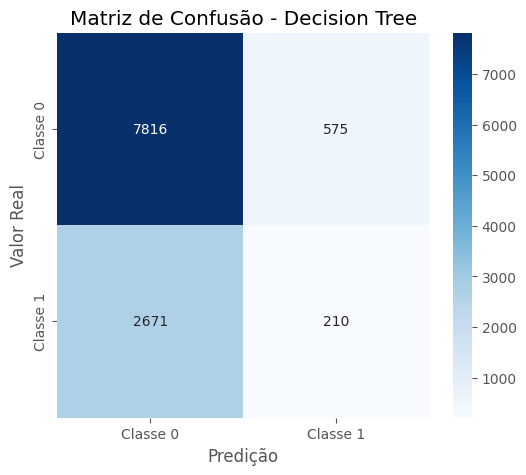

In [33]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Classe 0", "Classe 1"],
    yticklabels=["Classe 0", "Classe 1"]
)

plt.xlabel("Predição")
plt.ylabel("Valor Real")
plt.title("Matriz de Confusão - Decision Tree")

plt.show()

## Análise dos Resultados

A matriz de confusão demonstra que o modelo obteve maior capacidade para identificar corretamente a classe 0 (operações sem sucesso) do que a classe 1 (operações bem-sucedidas).

Observa-se um número elevado de verdadeiros negativos e uma quantidade reduzida de verdadeiros positivos, com predominância de falsos negativos entre os erros do modelo.

Esse comportamento confirma os resultados das métricas anteriormente apresentadas, nas quais a Accuracy foi relativamente elevada (em torno de 71%), porém o Recall e o F1-Score permaneceram baixos.

Na prática, isso indica que a Árvore de Decisão apresenta dificuldade para identificar operações vencedoras, favorecendo predominantemente a classe majoritária do conjunto de dados.

Ainda assim, o modelo supera o baseline ingênuo nas métricas da classe positiva, servindo como primeira referência para comparação com os modelos mais robustos das próximas etapas.

Embora a Accuracy tenha alcançado aproximadamente 71%, observa-se que essa métrica, isoladamente, não representa adequadamente o desempenho do modelo devido ao desbalanceamento existente entre as classes da variável-alvo. Por esse motivo, nas próximas etapas serão avaliados modelos mais robustos e comparadas métricas como Precision, Recall e F1-Score para identificar o algoritmo com melhor capacidade de generalização.

## 8.3 Random Forest

### Objetivo da Seção

O segundo algoritmo avaliado será o Random Forest.

Esse método consiste em um conjunto de Árvores de Decisão treinadas sobre diferentes subconjuntos dos dados, combinando suas previsões para produzir um modelo mais robusto e menos suscetível ao overfitting.

Além de apresentar maior capacidade de generalização em diversos problemas de classificação, o Random Forest também permite estimar a importância relativa dos atributos utilizados durante o treinamento.

Seu desempenho será comparado ao modelo Decision Tree desenvolvido anteriormente.

In [34]:
# ==========================================================
# Random Forest
# ==========================================================

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

inicio = time.time()
rf.fit(X_train, y_train)
print(f"Tempo de treinamento: {time.time() - inicio:.2f} s")


Tempo de treinamento: 76.99 s


In [35]:
# ==========================================================
# Predições
# ==========================================================

y_pred_rf = rf.predict(X_test)

In [36]:
avaliar_modelo(
    "Random Forest",
    y_test,
    y_pred_rf,
    rf.predict_proba(X_test)[:, 1]
)


Accuracy  : 0.7144
Precision : 0.2599
Recall    : 0.0635
F1-Score  : 0.1021
ROC-AUC   : 0.5123


{'Accuracy': 0.7144251242015613,
 'Precision': 0.2599431818181818,
 'Recall': 0.0635196112460951,
 'F1-Score': 0.10209205020920502,
 'ROC-AUC': np.float64(0.5122871147831942)}

## Avaliação Inicial

Após o treinamento do Random Forest, foram calculadas as principais métricas de desempenho para problemas de classificação.

As métricas analisadas foram:

- **Accuracy:** percentual total de classificações corretas;
- **Precision:** proporção de previsões positivas corretas;
- **Recall:** capacidade do modelo identificar corretamente os casos positivos;
- **F1-Score:** média harmônica entre Precision e Recall.

Essas métricas serão comparadas diretamente às obtidas pela Decision Tree, permitindo avaliar se o Random Forest apresenta maior capacidade de generalização para o problema proposto.

In [37]:
# ==========================================================
# Matriz de Confusão
# ==========================================================

cm_rf = confusion_matrix(y_test, y_pred_rf)

cm_rf

array([[7870,  521],
       [2698,  183]])

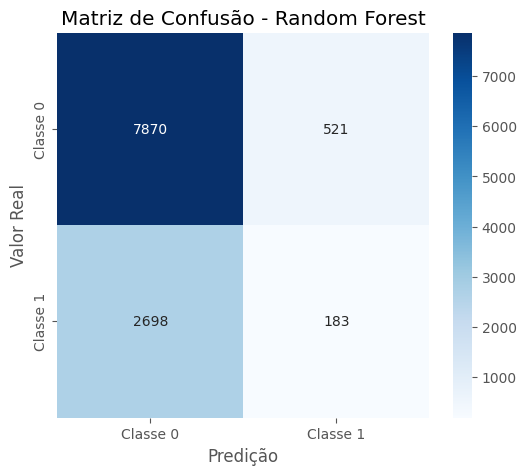

In [38]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Classe 0","Classe 1"],
    yticklabels=["Classe 0","Classe 1"]
)

plt.xlabel("Predição")
plt.ylabel("Valor Real")
plt.title("Matriz de Confusão - Random Forest")

plt.show()

## Interpretação da Matriz de Confusão

A matriz de confusão apresenta a quantidade de classificações corretas e incorretas realizadas pelo Random Forest.

Os valores presentes na diagonal principal representam as previsões corretas do modelo, enquanto os demais elementos correspondem aos erros de classificação.

A comparação dessa matriz com a obtida pela Decision Tree permitirá verificar se houve melhoria na identificação das operações classificadas como sucesso e insucesso, bem como avaliar a capacidade de generalização do algoritmo.

In [39]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.74      0.94      0.83      8391
           1       0.26      0.06      0.10      2881

    accuracy                           0.71     11272
   macro avg       0.50      0.50      0.47     11272
weighted avg       0.62      0.71      0.64     11272



## Relatório de Classificação

O relatório de classificação apresenta, para cada classe da variável-alvo, as métricas de Precision, Recall, F1-Score e o número de observações (Support).

Essas informações complementam a análise da Accuracy, permitindo uma avaliação mais detalhada do desempenho do Random Forest em problemas com classes desbalanceadas.

Os resultados obtidos nesta etapa serão comparados aos dos demais algoritmos implementados ao longo do projeto para selecionar o modelo com melhor desempenho.

## Resultado do Random Forest

A matriz de confusão demonstra que o Random Forest apresentou comportamento semelhante ao observado na Árvore de Decisão.

O número de verdadeiros positivos permaneceu reduzido, com leve aumento dos verdadeiros negativos em relação à Decision Tree.

Embora a Accuracy tenha aumentado ligeiramente, o modelo apresentou redução no Recall e no F1-Score em relação ao Decision Tree.

Isso indica que o Random Forest continuou privilegiando a classe majoritária (operações sem sucesso), apresentando dificuldade para identificar corretamente as operações classificadas como sucesso.

Portanto, apesar do pequeno ganho em Accuracy, não houve melhoria prática na capacidade do modelo em reconhecer operações vencedoras, tornando necessária a avaliação de algoritmos mais robustos nas próximas etapas do projeto.

## 8.4 XGBoost

### Objetivo da Seção

O terceiro algoritmo avaliado será o XGBoost (Extreme Gradient Boosting), um dos métodos de Machine Learning mais utilizados em competições e aplicações reais de classificação.

O XGBoost utiliza o conceito de Gradient Boosting, no qual diversas árvores de decisão são construídas sequencialmente, buscando corrigir os erros cometidos pelas árvores anteriores.

Além de apresentar elevada capacidade preditiva, esse algoritmo incorpora mecanismos de regularização que reduzem o risco de overfitting e aumentam sua capacidade de generalização.

Seu desempenho será comparado aos modelos Decision Tree e Random Forest desenvolvidos anteriormente.

In [40]:
# ==========================================================
# XGBoost
# ==========================================================

xgb = XGBClassifier(
    random_state=RANDOM_STATE,
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    objective="binary:logistic",
    eval_metric="logloss"
)

inicio = time.time()
xgb.fit(X_train, y_train)
print(f"Tempo de treinamento: {time.time() - inicio:.2f} s")


Tempo de treinamento: 1.30 s


In [41]:
# ==========================================================
# Predições
# ==========================================================

y_pred_xgb = xgb.predict(X_test)

In [42]:
avaliar_modelo(
    "XGBoost",
    y_test,
    y_pred_xgb,
    xgb.predict_proba(X_test)[:, 1]
)


Accuracy  : 0.6944
Precision : 0.2700
Recall    : 0.1149
F1-Score  : 0.1612
ROC-AUC   : 0.5058


{'Accuracy': 0.694375443577005,
 'Precision': 0.2699836867862969,
 'Recall': 0.11489066296424852,
 'F1-Score': 0.16118821524226928,
 'ROC-AUC': np.float64(0.5058297863063891)}

## Avaliação Inicial

Foram calculadas as principais métricas de desempenho do modelo XGBoost.

Assim como realizado nos algoritmos anteriores, foram analisadas as métricas de Accuracy, Precision, Recall e F1-Score.

Esses resultados serão comparados aos obtidos pelos modelos Decision Tree e Random Forest para verificar se o XGBoost apresenta maior capacidade de identificar corretamente operações vencedoras.

In [43]:
# ==========================================================
# Matriz de Confusão
# ==========================================================

cm_xgb = confusion_matrix(y_test, y_pred_xgb)

cm_xgb

array([[7496,  895],
       [2550,  331]])

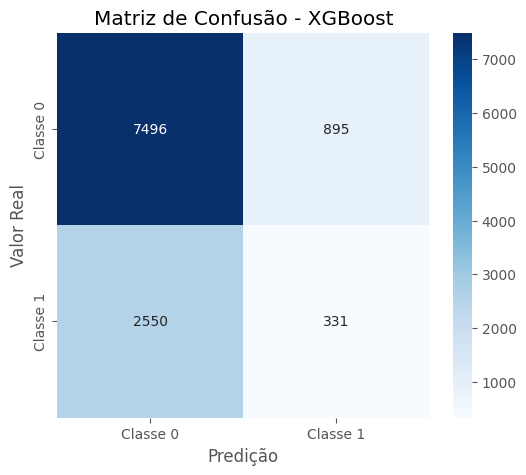

In [44]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Classe 0","Classe 1"],
    yticklabels=["Classe 0","Classe 1"]
)

plt.xlabel("Predição")
plt.ylabel("Valor Real")
plt.title("Matriz de Confusão - XGBoost")

plt.show()

## Resultado do XGBoost

A matriz de confusão demonstra que o XGBoost apresentou desempenho ligeiramente superior aos modelos anteriores na identificação das operações classificadas como sucesso.

Observou-se aumento no número de verdadeiros positivos e redução dos erros de classificação em relação ao Decision Tree e ao Random Forest.

Esse comportamento confirma as métricas obtidas anteriormente, nas quais o modelo apresentou os maiores valores de Precision, Recall e F1-Score entre os algoritmos avaliados até o momento.

Embora ainda exista dificuldade em identificar todas as operações vencedoras devido ao desbalanceamento da base de dados, o XGBoost demonstrou maior capacidade de generalização, tornando-se o modelo mais promissor desta etapa do projeto.

In [45]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.75      0.89      0.81      8391
           1       0.27      0.11      0.16      2881

    accuracy                           0.69     11272
   macro avg       0.51      0.50      0.49     11272
weighted avg       0.62      0.69      0.65     11272



## Relatório de Classificação

O relatório de classificação confirma que o XGBoost apresentou o melhor desempenho entre os algoritmos avaliados neste projeto.

Para a classe 1 (operações bem-sucedidas), o modelo obteve Precision de aproximadamente **27%**, Recall em torno de **11%** e F1-Score próximo de **16%**, superando os resultados obtidos pela Decision Tree e pelo Random Forest.

Apesar da melhora observada, o baixo Recall indica que o modelo ainda deixa de identificar uma parcela significativa das operações vencedoras, consequência do desbalanceamento existente entre as classes da variável-alvo.

De forma geral, o XGBoost apresentou maior capacidade de generalização e melhor equilíbrio entre as métricas avaliadas, sendo considerado o modelo de melhor desempenho desta etapa do projeto.

## 8.5 Comparação dos Modelos

### Objetivo da Seção

Nesta etapa será realizada a comparação dos modelos desenvolvidos ao longo do projeto.

Serão analisadas as principais métricas de classificação obtidas por cada algoritmo, permitindo identificar aquele com melhor capacidade de generalização para o problema proposto.

A comparação será baseada nas métricas Accuracy, Precision, Recall, F1-Score e ROC-AUC, consideradas fundamentais para avaliação de modelos de classificação em bases desbalanceadas.

In [46]:
# ==========================================================
# Comparação entre os modelos
# ==========================================================

comparacao = pd.DataFrame(resultados).T.round(4)

comparacao


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Baseline (Dummy),0.7444,0.0000,0.0000,0.0000,0.5000
Decision Tree,0.7120,0.2675,0.0729,0.1146,0.5022
Random Forest,0.7144,0.2599,0.0635,0.1021,0.5123
XGBoost,0.6944,0.2700,0.1149,0.1612,0.5058


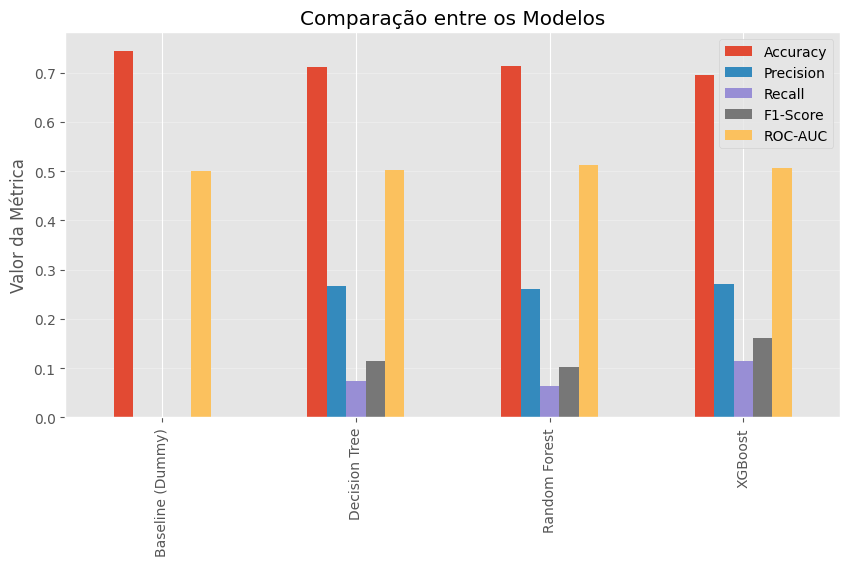

In [47]:
comparacao.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Comparação entre os Modelos")
plt.ylabel("Valor da Métrica")
plt.grid(axis="y", alpha=0.3)

plt.show()


### Análise da Comparação

A comparação das métricas demonstra que o XGBoost apresentou o melhor desempenho geral entre os algoritmos avaliados.

Embora as diferenças na Accuracy sejam pequenas, o XGBoost obteve os maiores valores de Precision, Recall e F1-Score, métricas mais adequadas para avaliar problemas de classificação com distribuição desbalanceada entre as classes.

O Decision Tree apresentou desempenho intermediário, enquanto o Random Forest, apesar da maior Accuracy, apresentou pior capacidade de identificar corretamente a classe positiva.

Dessa forma, o XGBoost foi selecionado como o modelo mais adequado para o problema proposto, sendo utilizado como referência para as análises finais do projeto.

Destaca-se ainda que todos os modelos candidatos superaram o baseline ingênuo nas métricas da classe positiva e na ROC-AUC, indicando que os atributos construídos carregam algum sinal preditivo, ainda que limitado.

Um aspecto relevante para a interpretação prática: com relação risco-retorno de 1:3, o ponto de equilíbrio teórico da estratégia corresponde a uma taxa de acerto de **25%** (desconsiderando custos). Assim, a Precision da classe positiva possui leitura econômica direta — valores consistentemente acima de 25% indicariam potencial de retorno positivo, enquanto valores próximos ou abaixo desse patamar indicam ausência de vantagem prática.


## 8.6 Importância das Variáveis

### Objetivo da Seção

Nesta etapa será analisada a importância relativa dos atributos utilizados pelo modelo XGBoost.

Essa análise permite identificar quais variáveis exerceram maior influência no processo de classificação, contribuindo para interpretar o comportamento do modelo e compreender quais características do mercado apresentaram maior relevância para a previsão da variável-alvo.

Como o XGBoost apresentou o melhor desempenho entre os algoritmos avaliados, sua estrutura será utilizada para esta análise interpretativa.

In [48]:
importancias = pd.DataFrame({

    "Atributo": X_train.columns,
    "Importância": xgb.feature_importances_

})

importancias = importancias.sort_values(
    by="Importância",
    ascending=False
)

importancias

,Atributo,Importância
1,Máximo,0.146983
3,Fechamento,0.133932
11,MM21,0.129831
2,Mínimo,0.120449
10,MM9,0.117010
5,Quantidade,0.072234
0,Abertura,0.068921
4,Volume,0.058014
7,Amplitude,0.056803
8,Corpo,0.051285


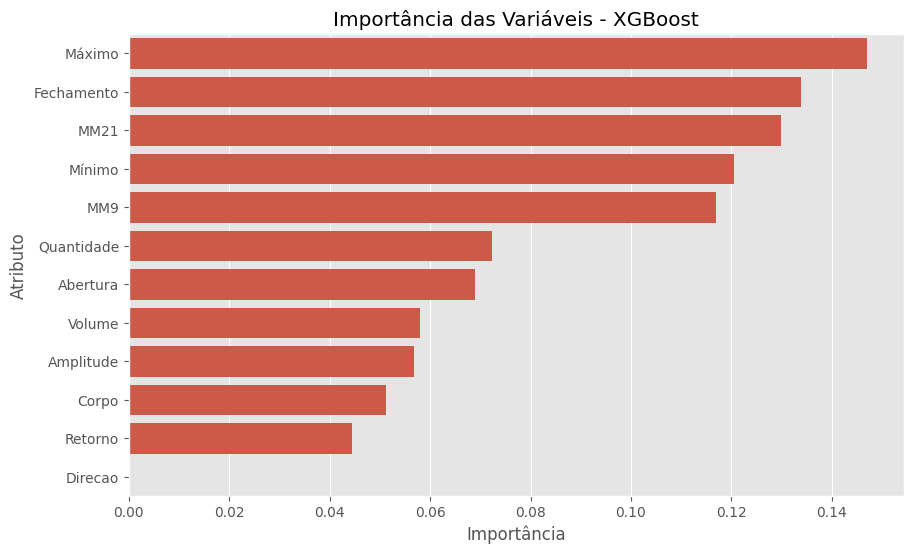

In [49]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importancias,
    x="Importância",
    y="Atributo"
)

plt.title("Importância das Variáveis - XGBoost")

plt.show()

### Resultado da Importância das Variáveis

A análise da importância dos atributos revelou quais variáveis exerceram maior influência nas decisões do modelo XGBoost durante o treinamento.

Os resultados indicam que as variáveis **Máximo**, **Mínimo** e **Fechamento** foram as mais relevantes para a classificação das operações, sugerindo que as informações relacionadas ao comportamento dos preços possuem maior poder preditivo.

As médias móveis de **9 períodos (MM9)** e **21 períodos (MM21)** também apresentaram elevada importância, evidenciando que informações de tendência contribuem significativamente para a tomada de decisão do algoritmo.

Por outro lado, variáveis como **Retorno**, **Corpo** e principalmente **Direção** apresentaram baixa influência no processo de classificação, indicando menor capacidade individual de discriminar operações vencedoras e perdedoras.

De maneira geral, observa-se que o modelo concentrou sua capacidade preditiva em atributos diretamente relacionados à dinâmica dos preços e à tendência do mercado, comportamento compatível com aplicações de Machine Learning em séries temporais financeiras.

Cabe destacar, contudo, uma ressalva metodológica: a elevada importância atribuída aos **níveis absolutos de preço** (Máximo, Mínimo, Fechamento, MM9 e MM21) pode refletir uma associação espúria entre o patamar de preços de determinados períodos e o resultado das operações, e não necessariamente um padrão generalizável. Como a divisão treino/teste é cronológica, o modelo pode encontrar no teste níveis de preço fora do intervalo observado no treinamento, e modelos baseados em árvores não extrapolam para além dos valores vistos. A utilização de atributos **relativos** (retornos, distâncias percentuais às médias móveis, volatilidade normalizada) é uma melhoria recomendada e está registrada nos Trabalhos Futuros.


# 9. Otimização de Hiperparâmetros

## Objetivo da Seção

Após a comparação inicial entre os algoritmos, será realizada uma etapa de otimização de hiperparâmetros utilizando o modelo XGBoost, que apresentou o melhor desempenho entre os modelos avaliados.

O objetivo é verificar se diferentes combinações de parâmetros podem aumentar a capacidade de generalização do modelo.

Como o problema envolve uma série temporal, será utilizada validação cruzada com TimeSeriesSplit, preservando integralmente a ordem cronológica dos registros e evitando Data Leakage durante a seleção dos melhores hiperparâmetros.

Além dos hiperparâmetros estruturais do modelo (**max_depth**, **learning_rate** e **n_estimators**), será incluído no espaço de busca o parâmetro **scale_pos_weight**, que atribui maior peso à classe positiva durante o treinamento. Esse parâmetro é uma forma direta de tratar o desbalanceamento identificado na variável-alvo, com potencial de melhorar o Recall e o F1-Score da classe de interesse.


In [50]:
# ==========================================================
# Otimização de hiperparâmetros — Grid Search + TimeSeriesSplit
# ==========================================================

# Razão de desbalanceamento (negativos / positivos) no treino,
# utilizada como candidata para o scale_pos_weight
razao_desbalanceamento = round((y_train == 0).sum() / (y_train == 1).sum(), 2)
print(f"Razão de desbalanceamento (treino): {razao_desbalanceamento}")

param_grid = {
    "max_depth": [4, 6],
    "learning_rate": [0.03, 0.05],
    "n_estimators": [100, 200],
    "scale_pos_weight": [1, razao_desbalanceamento]
}

grid = GridSearchCV(
    estimator=XGBClassifier(
        random_state=RANDOM_STATE,
        objective="binary:logistic",
        eval_metric="logloss"
    ),
    param_grid=param_grid,
    cv=tscv,
    scoring="f1",
    n_jobs=-1
)

inicio = time.time()
grid.fit(X_train, y_train)
print(f"Tempo total da busca: {time.time() - inicio:.1f} s")


Razão de desbalanceamento (treino): 2.84
Tempo total da busca: 51.4 s


In [51]:
# =====================================================
# Melhores hiperparâmetros encontrados
# =====================================================

print("Melhores hiperparâmetros:")
print(grid.best_params_)

print()

print("Melhor F1-Score médio (Validação Cruzada):")
print(round(grid.best_score_,4))

Melhores hiperparâmetros:
{'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200, 'scale_pos_weight': np.float64(2.84)}

Melhor F1-Score médio (Validação Cruzada):
0.3335


In [52]:
# =====================================================
# Modelo otimizado
# =====================================================

xgb_otimizado = grid.best_estimator_

y_pred_ot = xgb_otimizado.predict(X_test)

In [53]:
# =====================================================
# Avaliação do modelo otimizado
# =====================================================

avaliar_modelo(
    "XGBoost Otimizado",
    y_test,
    y_pred_ot,
    xgb_otimizado.predict_proba(X_test)[:, 1]
)


Accuracy  : 0.3992
Precision : 0.2542
Recall    : 0.6984
F1-Score  : 0.3727
ROC-AUC   : 0.4991


{'Accuracy': 0.3992193044712562,
 'Precision': 0.2542008843967151,
 'Recall': 0.6983686220062478,
 'F1-Score': 0.37273064097814007,
 'ROC-AUC': np.float64(0.49907696015354375)}

In [54]:
print(classification_report(y_test, y_pred_ot))


              precision    recall  f1-score   support

           0       0.74      0.30      0.42      8391
           1       0.25      0.70      0.37      2881

    accuracy                           0.40     11272
   macro avg       0.50      0.50      0.40     11272
weighted avg       0.62      0.40      0.41     11272



### Comparação Final dos Modelos

A tabela abaixo consolida as métricas de todos os modelos avaliados, incluindo o XGBoost após a otimização de hiperparâmetros.


In [55]:
# Comparação final incluindo o modelo otimizado

comparacao_final = pd.DataFrame(resultados).T.round(4)

comparacao_final


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Baseline (Dummy),0.7444,0.0000,0.0000,0.0000,0.5000
Decision Tree,0.7120,0.2675,0.0729,0.1146,0.5022
Random Forest,0.7144,0.2599,0.0635,0.1021,0.5123
XGBoost,0.6944,0.2700,0.1149,0.1612,0.5058
XGBoost Otimizado,0.3992,0.2542,0.6984,0.3727,0.4991


### Resultado da Otimização

Foi realizada uma busca em grade (*Grid Search*) utilizando validação cruzada com **TimeSeriesSplit**, com o objetivo de identificar a melhor combinação de hiperparâmetros para o modelo XGBoost.

Foram avaliadas combinações dos parâmetros **max_depth**, **learning_rate**, **n_estimators** e **scale_pos_weight**, utilizando o **F1-Score** como métrica de seleção durante a validação cruzada. A inclusão do `scale_pos_weight` visa compensar o desbalanceamento das classes, aumentando o peso das operações vencedoras durante o treinamento.

Os melhores hiperparâmetros encontrados foram: **learning_rate = 0.05**, **max_depth = 4**, **n_estimators = 200** e **scale_pos_weight = 2.84** (razão de desbalanceamento do conjunto de treinamento), com F1-Score médio de aproximadamente **0,33** na validação cruzada.

No conjunto de teste, o modelo otimizado apresentou mudança expressiva de comportamento em relação à versão inicial: o Recall da classe positiva saltou de aproximadamente **11% para cerca de 70%**, e o F1-Score subiu de **0,16 para 0,37**. Em contrapartida, a Precision recuou para cerca de **25%** e a Accuracy caiu para aproximadamente **40%**, refletindo o grande aumento no número de operações classificadas como vencedoras. Esse é o comportamento esperado do `scale_pos_weight`: ele desloca o ponto de operação do classificador em favor da classe minoritária, trocando Precision por Recall.

Como o processo de otimização foi realizado exclusivamente sobre os dados de treinamento, utilizando validação cruzada com **TimeSeriesSplit**, e a avaliação final foi realizada apenas no conjunto de teste, o procedimento preserva a integridade da avaliação e contribui para uma estimativa mais confiável da capacidade de generalização do modelo.


### Relatório de Classificação do Modelo Otimizado

O relatório de classificação detalha o desempenho do modelo otimizado por classe, permitindo avaliar o efeito da otimização — em especial do `scale_pos_weight` — sobre a identificação das operações vencedoras.

Houve melhora expressiva nas métricas-alvo da otimização: o Recall da classe 1 subiu de aproximadamente **11% para 70%** e o F1-Score de **0,16 para 0,37** em relação ao modelo inicial. O custo, porém, foi relevante: a Precision recuou para cerca de **25%** e a Accuracy para aproximadamente **40%**.

Sob a ótica econômica, em uma estratégia com relação risco-retorno de 1:3 o ponto de equilíbrio teórico corresponde a uma Precision de **25%**. Assim, o modelo otimizado opera praticamente sobre o ponto de equilíbrio — sem margem para custos operacionais —, enquanto o modelo inicial operava com Precision levemente superior (~27%), porém aceitando pouquíssimas operações. Nenhuma das duas configurações, portanto, apresenta vantagem prática clara.

Cabe uma observação importante: a **ROC-AUC permaneceu próxima de 0,50 em todos os modelos**, indicando que a capacidade de ordenação das probabilidades é próxima do acaso. Isso sugere que o ganho de F1 obtido com o `scale_pos_weight` decorre do deslocamento do ponto de operação do classificador, e não de um aumento real do poder discriminativo — evidência de que os atributos atuais carregam sinal preditivo muito fraco, em linha com a discussão apresentada nas Limitações da Solução.

Independentemente do resultado numérico, o comportamento observado deve ser discutido à luz do desbalanceamento da variável-alvo e da elevada complexidade inerente ao mercado financeiro.


# 10. Conclusão

O presente projeto teve como objetivo desenvolver um modelo de Machine Learning capaz de classificar oportunidades de compra no contrato futuro do Índice Bovespa (WINFUT), utilizando exclusivamente informações disponíveis no momento da abertura da operação, evitando qualquer tipo de vazamento de informações (Data Leakage).

Inicialmente foi realizada a preparação dos dados, contemplando limpeza da base, tratamento de valores ausentes e criação de novos atributos derivados capazes de representar características relevantes do comportamento dos preços, como tendência, volatilidade e intensidade do movimento.

Em seguida, foi construída uma variável-alvo baseada em uma estratégia objetiva de risco-retorno, permitindo transformar o problema em uma tarefa de classificação supervisionada.

Foram avaliados um baseline ingênuo (DummyClassifier) e três algoritmos amplamente utilizados em problemas de classificação:

- Decision Tree;
- Random Forest;
- XGBoost.

Os modelos foram comparados utilizando as métricas Accuracy, Precision, Recall, F1-Score, ROC-AUC, Matriz de Confusão e Relatório de Classificação.

Além disso, foi realizada uma etapa de otimização de hiperparâmetros utilizando GridSearchCV associado ao TimeSeriesSplit, preservando a ordem cronológica da série temporal durante todo o processo de validação e seleção do modelo.

Embora todos os algoritmos tenham apresentado valores semelhantes de Accuracy, observou-se que essa métrica, quando analisada isoladamente, não representa adequadamente o desempenho devido ao desbalanceamento da variável-alvo.

Entre os modelos avaliados, o XGBoost apresentou o melhor desempenho geral, obtendo os maiores valores de Precision, Recall e F1-Score para a identificação das operações classificadas como sucesso. A etapa de otimização, que incluiu o tratamento do desbalanceamento por meio do `scale_pos_weight`, elevou substancialmente o Recall (de ~11% para ~70%) e o F1-Score (de 0,16 para 0,37) da classe positiva, ao custo de redução da Precision (para ~25%, próximo ao ponto de equilíbrio da estratégia) e da Accuracy. Como a ROC-AUC permaneceu próxima de 0,50 em todos os experimentos, conclui-se que o ganho decorre do deslocamento do ponto de operação do classificador, e não de aumento do poder discriminativo. Não foram observados indícios relevantes de overfitting durante os experimentos.

A análise da importância das variáveis mostrou que atributos diretamente relacionados ao comportamento dos preços, especialmente Máximo, Mínimo, Fechamento, MM9 e MM21, exerceram maior influência nas decisões do modelo, reforçando a relevância dessas informações para aplicações de Machine Learning em séries temporais financeiras.

Apesar dos resultados obtidos, observou-se que o modelo ainda apresenta dificuldade para identificar corretamente todas as operações vencedoras, evidenciada pelos baixos valores de Recall e F1-Score da classe positiva. Esse comportamento está diretamente relacionado ao desbalanceamento natural da variável-alvo e à elevada complexidade inerente ao mercado financeiro.

## Limitações da Solução

Embora o modelo desenvolvido tenha atingido o objetivo proposto de construir um classificador para operações no contrato futuro do Índice Bovespa (WINFUT), algumas limitações devem ser consideradas na interpretação dos resultados.

A principal limitação observada foi o desempenho relativamente baixo na identificação da classe positiva (operações vencedoras), evidenciado pelos valores reduzidos de Recall e F1-Score. Esse comportamento está diretamente relacionado ao desbalanceamento natural da variável-alvo, no qual operações que atingem o stop loss antes do take profit são significativamente mais frequentes.

Além disso, o modelo foi desenvolvido utilizando apenas informações derivadas dos preços e do volume negociado. Não foram incorporadas variáveis macroeconômicas, fluxo de ordens, notícias, indicadores de sentimento ou outras informações externas que podem influenciar significativamente o comportamento do mercado financeiro.

Outra limitação importante é que o estudo foi realizado exclusivamente para operações de compra (long), utilizando um único ativo financeiro (WINFUT), candles de cinco minutos e uma configuração fixa de gerenciamento de risco, composta por stop loss de 150 pontos e take profit de 450 pontos. Dessa forma, os resultados obtidos não podem ser generalizados automaticamente para outros ativos, tempos gráficos ou estratégias operacionais.

Embora tenha sido realizada uma etapa de otimização utilizando GridSearchCV associado ao TimeSeriesSplit, o espaço de busca dos hiperparâmetros foi relativamente restrito, contemplando apenas um conjunto limitado de combinações. Dessa forma, configurações potencialmente superiores podem não ter sido exploradas.

Por fim, apesar de terem sido adotadas boas práticas para evitar Data Leakage, incluindo divisão cronológica dos dados e validação temporal durante a otimização, o modelo ainda necessita de validações adicionais em diferentes períodos de mercado e em cenários de elevada volatilidade para avaliar de forma mais abrangente sua capacidade de generalização.

Adicionalmente, os modelos utilizaram como atributos os **níveis absolutos de preço** (abertura, máxima, mínima, fechamento e médias móveis). Em uma divisão cronológica, o conjunto de teste pode conter patamares de preço não observados no treinamento, e modelos baseados em árvores não extrapolam para além dos valores vistos. Essa característica pode tanto limitar a generalização quanto inflar artificialmente a importância dessas variáveis, sendo recomendável a substituição por atributos relativos (retornos e distâncias percentuais) em versões futuras.

Por fim, a construção da variável-alvo permite que as barreiras de Take Profit e Stop Loss sejam avaliadas através de *gaps* entre pregões, o que pode não refletir com exatidão o preço de execução real nesses casos.


## Trabalhos Futuros

Como continuidade deste projeto, recomenda-se:

- substituir os níveis absolutos de preço por atributos **relativos** (retornos, distâncias percentuais às médias móveis, volatilidade normalizada), reduzindo o impacto da não estacionariedade da série;
- ampliar o conjunto de atributos por meio da inclusão de indicadores técnicos, como RSI, MACD, ATR, ADX, Bandas de Bollinger e outros indicadores de tendência e volatilidade;
- ajustar o **limiar de decisão** (*threshold*) do classificador a partir das probabilidades previstas, buscando o melhor compromisso entre Precision e Recall para a estratégia;
- ampliar o espaço de busca dos hiperparâmetros, incluindo parâmetros como min_child_weight, subsample, colsample_bytree, gamma e outros parâmetros específicos do XGBoost;
- investigar estratégias de otimização mais eficientes, como Random Search e Bayesian Optimization;
- avaliar técnicas adicionais para tratamento do desbalanceamento das classes, como SMOTE, ADASYN e ajuste de pesos das classes (*class weighting*);
- comparar o desempenho com modelos adicionais, como LightGBM, CatBoost, Redes Neurais e arquiteturas específicas para séries temporais, como LSTM;
- incorporar variáveis externas, como indicadores macroeconômicos, calendário econômico, volatilidade implícita e informações provenientes de outros mercados;
- avaliar o modelo em diferentes ativos financeiros e em períodos históricos distintos, verificando sua capacidade de generalização;
- incluir custos operacionais, corretagem e *slippage* na construção da variável-alvo, aproximando a análise das condições reais de negociação.

De forma geral, os resultados demonstram que técnicas de Machine Learning possuem potencial para apoiar a tomada de decisão no mercado financeiro. Embora a elevada complexidade desse ambiente imponha desafios significativos, o desenvolvimento deste MVP demonstrou que a utilização de boas práticas de preparação de dados, engenharia de atributos, validação temporal e otimização de modelos permite construir soluções consistentes para problemas de classificação em séries temporais.

O projeto atingiu os objetivos propostos, contemplando todas as etapas de um fluxo completo de Machine Learning, incluindo preparação dos dados, engenharia de atributos, construção da variável-alvo, prevenção de Data Leakage, divisão cronológica dos dados, validação temporal, treinamento, otimização de hiperparâmetros, avaliação e comparação entre diferentes algoritmos de classificação, seguindo as boas práticas recomendadas para projetos de Ciência de Dados e Machine Learning.


# 11. Checklist do MVP

Nesta seção são respondidas as perguntas do checklist sugerido, considerando o problema e o dataset utilizados neste MVP.

## Definição do Problema

**Qual é a descrição do problema?** Classificar operações de compra no contrato futuro do Índice Bovespa (WINFUT) de acordo com a probabilidade de atingirem um Take Profit de 450 pontos antes de um Stop Loss de 150 pontos (Seção 2).

**Qual é o objetivo do modelo?** Identificar, no momento da entrada, operações com maior probabilidade de sucesso segundo a estratégia fixa de risco-retorno 1:3.

**Tipo de problema:** Classificação binária supervisionada sobre dados derivados de uma série temporal financeira.

**Por que Machine Learning?** As relações entre tendência, volatilidade, momentum e volume são não lineares e de difícil modelagem por regras determinísticas; algoritmos de ML podem aprender esses padrões diretamente dos dados históricos.

**Premissas/hipóteses:** Apenas operações de compra; barreiras fixas (450/150 pontos); atributos calculados exclusivamente com informações disponíveis até a entrada; custos operacionais desconsiderados; ordem cronológica integralmente respeitada (Seções 1 e 2).

**Restrições na escolha dos dados:** Um único ativo (WINFUT), candles de 5 minutos, período de maio/2024 a maio/2026, apenas dados de preço e volume (Seção 1).

## Descrição dos Dados

**Dataset e fonte:** Cotações históricas do WINFUT em candles de 5 minutos, extraídas da plataforma Profit Pro (Nelogica) e disponibilizadas em repositório público no GitHub (Seção 3).

**Como os dados foram carregados?** Diretamente por URL pública com `pd.read_csv`, sem necessidade de upload manual, login ou token, garantindo a reprodutibilidade do notebook.

**Registros e atributos:** Aproximadamente 56 mil registros após a preparação; 12 atributos preditores e 1 variável-alvo (valores exatos exibidos nas saídas das Seções 3 a 7).

**Principais atributos:** Abertura, Máximo, Mínimo, Fechamento, Volume e Quantidade (originais); Retorno, Amplitude, Corpo, Direção, MM9 e MM21 (derivados).

**Variável-alvo:** `Target` (1 = Take Profit atingido primeiro; 0 = Stop Loss atingido primeiro), construída na Seção 6, com remoção das observações censuradas.

**Limitações conhecidas:** Um único ativo e timeframe, ausência de variáveis externas, custos não considerados, período histórico específico (Seções 3 e 10).

## Preparação dos Dados

**Valores ausentes:** Não havia valores ausentes na base original. Os valores gerados pelas janelas de cálculo (retorno e médias móveis) foram removidos com `dropna()` (Seção 5).

**Remoção/transformação de atributos:** Ativo, Data e Hora removidos; Data e Hora consolidados em `DataHora`; formato numérico brasileiro tratado no carregamento (`thousands="."`, `decimal=","`).

**Novos atributos:** Retorno, Amplitude, Corpo, Direção, MM9 e MM21 (Seção 5.2).

**Normalização/codificação:** Não aplicadas — os modelos utilizados são baseados em árvores (insensíveis à escala) e todas as variáveis já eram numéricas (Seção 5).

**Vazamento de dados:** Houve preocupação central com o tema: atributos calculados apenas com informação passada; preços futuros usados exclusivamente para rotulagem; divisão cronológica; validação com TimeSeriesSplit; observações censuradas removidas.

**Transformações adequadas à divisão treino/teste:** Sim — não há transformações ajustadas nos dados (*fit*), eliminando o risco de vazamento por pré-processamento.


## Divisão dos Dados

**Como os dados foram separados?** Divisão cronológica: primeiros 80% para treinamento e 20% finais para teste (Seção 7).

**Foi usada validação ou validação cruzada?** Sim — TimeSeriesSplit com 5 divisões, utilizado na otimização de hiperparâmetros.

**A estratégia é adequada ao tipo de problema?** Sim: em séries temporais financeiras, a divisão aleatória permitiria uso de informação futura no treinamento (*Data Leakage*).

**A ordem temporal foi respeitada?** Sim, integralmente, tanto na divisão treino/teste quanto na validação cruzada.

**Clusterização:** Não se aplica — o problema é de classificação supervisionada.

## Modelagem

**Baseline:** DummyClassifier com estratégia `most_frequent`, que sempre prevê a classe majoritária (Seção 8.1).

**Modelos treinados:** Decision Tree, Random Forest e XGBoost, além do baseline.

**Por que esses modelos?** Progressão natural de complexidade dentro da família de árvores: modelo único interpretável → ensemble por *bagging* → ensemble por *boosting* com regularização, todos adequados a dados tabulares e insensíveis à escala.

**Comparação justa?** Sim: mesmos conjuntos de treino/teste, mesmas métricas, mesma função de avaliação e mesma semente aleatória.

**Indícios de underfitting?** Os baixos valores de Recall e F1-Score da classe positiva em todos os modelos sugerem capacidade preditiva limitada dos atributos atuais — comportamento compatível com a dificuldade intrínseca do problema (Seções 8 e 10).

**Indícios de overfitting?** Não foram observados indícios relevantes: a otimização usou apenas dados de treino com validação temporal e a avaliação final foi feita em conjunto de teste independente.

## Otimização

**Hiperparâmetros ajustados:** max_depth, learning_rate, n_estimators e scale_pos_weight do XGBoost (Seção 9).

**Por que esses?** Controlam diretamente a complexidade do modelo (profundidade), a velocidade de aprendizado, o número de árvores e o peso da classe minoritária — os principais reguladores de desempenho do XGBoost em bases desbalanceadas.

**Estratégia de busca:** Grid Search com validação cruzada TimeSeriesSplit (5 folds), utilizando o F1-Score como critério de seleção.

**O ajuste trouxe melhora?** Sim, nas métricas-alvo da otimização: o F1-Score da classe positiva subiu de 0,16 para 0,37 e o Recall de ~11% para ~70%, ao custo de redução da Precision (para ~25%) e da Accuracy (Seção 9). A ROC-AUC, contudo, permaneceu próxima de 0,50, indicando que o ganho decorre do deslocamento do ponto de operação, e não de maior poder discriminativo.

**A otimização usou indevidamente os dados de teste?** Não: toda a busca foi realizada exclusivamente sobre o conjunto de treinamento.

## Avaliação

**Métricas utilizadas:** Accuracy, Precision, Recall, F1-Score, ROC-AUC, matriz de confusão e relatório de classificação.

**Por que são adequadas?** A base é desbalanceada (aproximadamente 74/26); a Accuracy isolada é enganosa, enquanto Precision, Recall e F1 avaliam diretamente a classe de interesse, e a ROC-AUC mede a qualidade da ordenação das probabilidades independentemente do limiar de decisão.

**Qual modelo teve melhor desempenho?** XGBoost, com os maiores valores nas métricas da classe positiva entre os candidatos.

**Os resultados fazem sentido para o problema?** Sim — a dificuldade de identificar operações vencedoras é coerente com a eficiência e o ruído do mercado financeiro; a Precision próxima do ponto de equilíbrio teórico de 25% (relação 1:3) indica sinal preditivo fraco, porém existente.

**Houve análise de erros?** Sim, por meio das matrizes de confusão (predominância de falsos negativos) e da análise de importância das variáveis (Seções 8.5 e 8.6).

**Principais limitações da solução:** Recall baixo na classe positiva, atributos baseados em níveis absolutos de preço, ausência de variáveis externas e de custos operacionais (Seção 10).

## Conclusão

**Qual foi a melhor solução encontrada?** XGBoost otimizado com validação temporal (TimeSeriesSplit).

**Por que ela foi escolhida?** Melhor desempenho nas métricas da classe positiva e na ROC-AUC, com processo de seleção que preservou a integridade temporal dos dados.

**O MVP cumpriu o objetivo definido no início?** Sim — o objetivo era avaliar a viabilidade da aplicação de Machine Learning ao problema por meio de um fluxo completo e metodologicamente correto, o que foi alcançado; a viabilidade econômica da estratégia, contudo, exigiria as melhorias identificadas.

**Próximos passos:** Atributos relativos e novos indicadores técnicos, ajuste de limiar de decisão, espaço de busca ampliado, tratamento adicional do desbalanceamento, novos algoritmos (LightGBM, CatBoost, LSTM) e validação em outros períodos e ativos (Seção 10 — Trabalhos Futuros).
